# Explainable AI — Phase I: Logical Model

## Payment Difficulty Prediction using a Decision Tree

The objective of this notebook is to develop and interpret a logical model
for predicting `payment_difficulty_next_month`.

The analysis focuses on:

- exploratory data analysis and data quality;
- five-fold cross-validation for model selection;
- the trade-off between predictive performance and interpretability;
- global interpretation of the learned model;
- local explanations for individual predictions.

For Phase I, the logical model is implemented using a decision tree.

In [1]:
%pip install -q numpy pandas matplotlib scikit-learn gosdt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings(
    "ignore",
    message=".*force_all_finite.*",
    category=FutureWarning
)

from pathlib import Path

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

RANDOM_STATE = 42

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt

FIGURES_DIR = Path("../report/images")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

_original_show = plt.show
_figure_counter = 1

def save_and_show(*args, **kwargs):
    global _figure_counter

    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)

        filename = FIGURES_DIR / f"figure_{_figure_counter:02d}.png"

        fig.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )

        print(f"Saved: {filename}")
        _figure_counter += 1

    _original_show(*args, **kwargs)

plt.show = save_and_show

In [4]:
DATA_DIR = Path("../data")

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train shape: (25000, 17)
Test shape:  (5000, 16)


In [5]:
train.head()

,row_id,credit_limit,sex,education,marital_status,age,latest_repayment_status,maximum_repayment_delay_6m,delayed_months_6m,average_bill_6m,bill_change_sep_to_apr,total_payment_6m,payment_to_bill_ratio_6m,zero_payment_months_6m,utilization_sep,repayment_assistance_plan,payment_difficulty_next_month
0,CR26-120473,80000,male,university,married,54,0,0,0,24600,3700,10300,0.07,0,0.33,no,0
1,CR26-127004,20000,male,university,single,30,0,0,0,21100,21000,6700,0.05,0,1.98,no,0
2,CR26-116408,230000,female,graduate_school,married,35,0,0,0,1700,3600,5100,0.49,1,0.03,no,0
3,CR26-125768,150000,female,university,married,51,0,0,0,76100,-8800,15400,0.03,0,0.48,no,0
4,CR26-118040,500000,male,graduate_school,married,43,0,0,0,121600,26200,25000,0.03,0,0.25,yes,0


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   row_id                         25000 non-null  object 
 1   credit_limit                   25000 non-null  int64  
 2   sex                            25000 non-null  object 
 3   education                      25000 non-null  object 
 4   marital_status                 25000 non-null  object 
 5   age                            25000 non-null  int64  
 6   latest_repayment_status        25000 non-null  int64  
 7   maximum_repayment_delay_6m     25000 non-null  int64  
 8   delayed_months_6m              25000 non-null  int64  
 9   average_bill_6m                25000 non-null  int64  
 10  bill_change_sep_to_apr         25000 non-null  int64  
 11  total_payment_6m               25000 non-null  int64  
 12  payment_to_bill_ratio_6m       25000 non-null 

In [7]:
print("Train columns:")
display(train.columns.to_frame(index=False, name="column"))

print("\nColumns only present in train:")
print(set(train.columns) - set(test.columns))

print("\nColumns only present in test:")
print(set(test.columns) - set(train.columns))

Train columns:


,column
0,row_id
1,credit_limit
2,sex
3,education
4,marital_status
5,age
6,latest_repayment_status
7,maximum_repayment_delay_6m
8,delayed_months_6m
9,average_bill_6m



Columns only present in train:
{'payment_difficulty_next_month'}

Columns only present in test:
set()


## 1. Data quality and exploratory analysis

Before fitting the model, we inspect the dataset structure, missing values,
duplicates, target distribution and predictor distributions.

In [8]:
missing = (
    train.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_values")
)

missing["percentage"] = (
    missing["missing_values"] / len(train) * 100
)

missing

,missing_values,percentage
row_id,0,0.0
credit_limit,0,0.0
sex,0,0.0
education,0,0.0
marital_status,0,0.0
age,0,0.0
latest_repayment_status,0,0.0
maximum_repayment_delay_6m,0,0.0
delayed_months_6m,0,0.0
average_bill_6m,0,0.0


In [9]:
print(f"Duplicated rows: {train.duplicated().sum()}")
print(f"Duplicated row_id: {train['row_id'].duplicated().sum()}")

Duplicated rows: 0
Duplicated row_id: 0


In [10]:
TARGET = "payment_difficulty_next_month"

target_counts = train[TARGET].value_counts().sort_index()
target_pct = train[TARGET].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct
})

target_summary

,count,percentage
payment_difficulty_next_month,,
0,19697,78.788
1,5303,21.212


Saved: ../report/images/figure_01.png


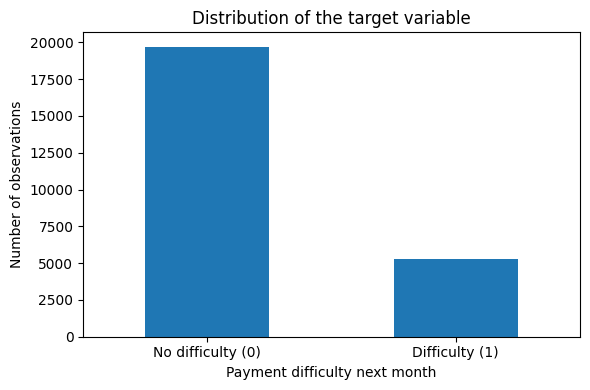

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))

target_counts.plot(kind="bar", ax=ax)

ax.set_title("Distribution of the target variable")
ax.set_xlabel("Payment difficulty next month")
ax.set_ylabel("Number of observations")
ax.set_xticklabels(
    ["No difficulty (0)", "Difficulty (1)"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [12]:
majority_class = train[TARGET].mode()[0]

baseline_predictions = np.full(
    shape=len(train),
    fill_value=majority_class
)

baseline_accuracy = accuracy_score(
    train[TARGET],
    baseline_predictions
)

baseline_balanced_accuracy = balanced_accuracy_score(
    train[TARGET],
    baseline_predictions
)

print(f"Majority class: {majority_class}")
print(f"Baseline accuracy:          {baseline_accuracy:.4f}")
print(f"Baseline balanced accuracy: {baseline_balanced_accuracy:.4f}")

Majority class: 0
Baseline accuracy:          0.7879
Baseline balanced accuracy: 0.5000


In [13]:
ID_COLUMN = "row_id"

X = train.drop(columns=[ID_COLUMN, TARGET])
y = train[TARGET]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (25000, 15)
y shape: (25000,)


In [14]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Categorical features:
['sex', 'education', 'marital_status', 'repayment_assistance_plan']

Numeric features:
['credit_limit', 'age', 'latest_repayment_status', 'maximum_repayment_delay_6m', 'delayed_months_6m', 'average_bill_6m', 'bill_change_sep_to_apr', 'total_payment_6m', 'payment_to_bill_ratio_6m', 'zero_payment_months_6m', 'utilization_sep']


In [15]:
for column in categorical_features:
    print(f"\n--- {column} ---")

    summary = pd.DataFrame({
        "count": train[column].value_counts(dropna=False),
        "percentage": train[column].value_counts(
            normalize=True,
            dropna=False
        ) * 100
    })

    display(summary)


--- sex ---


,count,percentage
sex,,
female,15130,60.52
male,9870,39.48



--- education ---


,count,percentage
education,,
university,11675,46.700
graduate_school,8820,35.280
high_school,4107,16.428
unknown,289,1.156
other,109,0.436



--- marital_status ---


,count,percentage
marital_status,,
single,13310,53.240
married,11368,45.472
other_or_unknown,322,1.288



--- repayment_assistance_plan ---


,count,percentage
repayment_assistance_plan,,
no,19680,78.72
yes,5320,21.28


In [16]:
numeric_summary = train[numeric_features].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
credit_limit,25000.0,167740.947200,129975.980819,10000.0,50000.00,140000.00,240000.00,1000000.0
age,25000.0,35.500840,9.243907,21.0,28.00,34.00,41.00,79.0
latest_repayment_status,25000.0,-0.018080,1.120519,-2.0,-1.00,0.00,0.00,8.0
maximum_repayment_delay_6m,25000.0,0.680880,1.070985,0.0,0.00,0.00,2.00,8.0
delayed_months_6m,25000.0,0.833120,1.552059,0.0,0.00,0.00,1.00,6.0
average_bill_6m,25000.0,44910.436000,63267.261940,-56000.0,4700.00,21000.00,57100.00,877300.0
bill_change_sep_to_apr,25000.0,12389.508000,44068.853510,-403600.0,-3000.00,900.00,19900.00,708300.0
total_payment_6m,25000.0,31635.048000,57337.817230,0.0,6700.00,14400.00,33700.00,2314200.0
payment_to_bill_ratio_6m,25000.0,0.374324,0.591434,0.0,0.04,0.09,0.60,5.0
zero_payment_months_6m,25000.0,1.233520,1.722065,0.0,0.00,0.00,2.00,6.0


Saved: ../report/images/figure_02.png


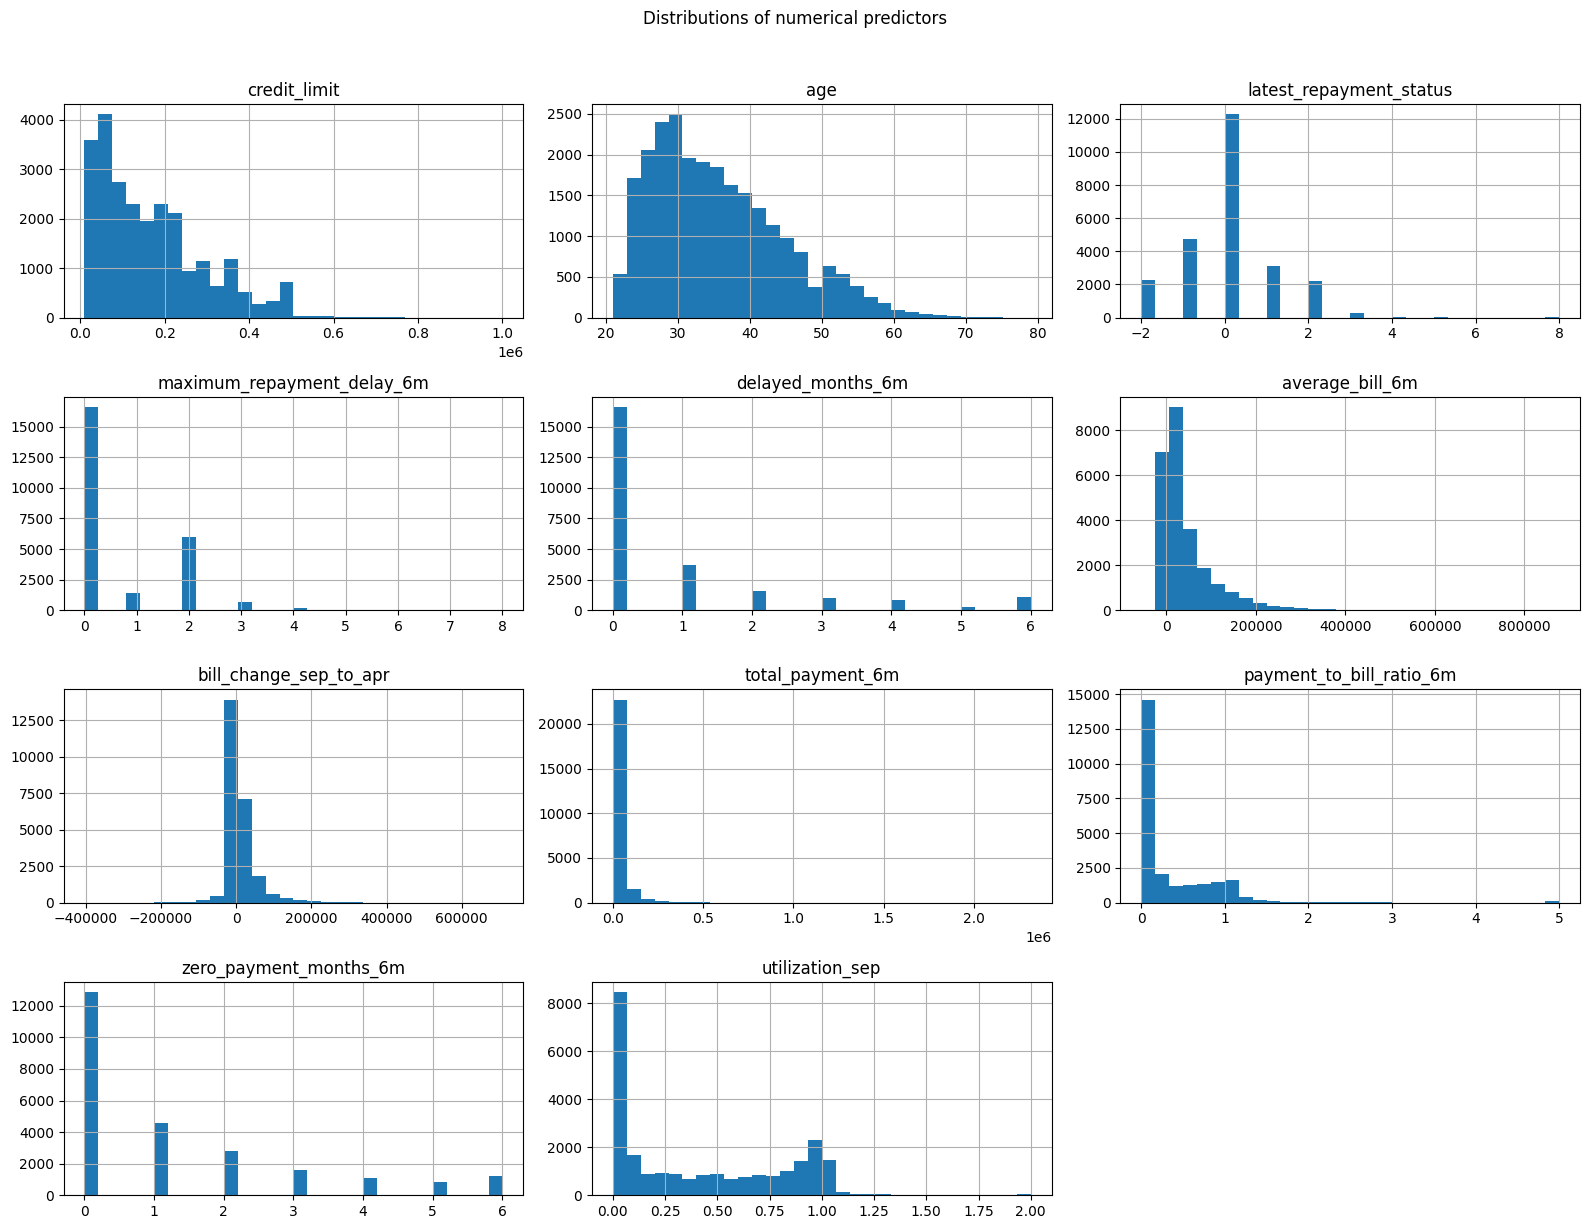

In [17]:
train[numeric_features].hist(
    bins=30,
    figsize=(16, 12)
)

plt.suptitle(
    "Distributions of numerical predictors",
    y=1.02
)

plt.tight_layout()
plt.show()

In [18]:
for column in categorical_features:
    difficulty_rate = (
        train
        .groupby(column, observed=True)[TARGET]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )

    difficulty_rate["mean"] *= 100

    difficulty_rate = difficulty_rate.rename(
        columns={"mean": "difficulty_rate_pct"}
    )

    print(f"\n--- {column} ---")
    display(difficulty_rate)


--- sex ---


,difficulty_rate_pct,count
sex,,
male,21.813576,9870
female,20.819564,15130



--- education ---


,difficulty_rate_pct,count
education,,
high_school,23.837351,4107
university,22.064240,11675
unknown,21.453287,289
graduate_school,18.945578,8820
other,13.761468,109



--- marital_status ---


,difficulty_rate_pct,count
marital_status,,
single,21.998497,13310
married,20.328994,11368
other_or_unknown,19.875776,322



--- repayment_assistance_plan ---


,difficulty_rate_pct,count
repayment_assistance_plan,,
yes,32.669173,5320
no,18.114837,19680


### Interpretation caution: repayment assistance

`repayment_assistance_plan` indicates whether a temporary support or
restructuring plan was recorded before the outcome month.

The assignment of assistance is not random. Clients may receive assistance
because the lender has already observed signs of financial stress.

Therefore, differences in payment-difficulty rates between clients with and
without an assistance plan must be interpreted as **predictive associations**,
not as causal effects of receiving assistance.

## 2. Model development strategy

The dataset presents a moderate class imbalance: approximately 79% of the
observations belong to class 0 and 21% to class 1. Therefore, accuracy alone
is not an appropriate criterion for model selection.

Model selection and hyperparameter choices are performed using stratified
five-fold cross-validation. Stratification preserves approximately the class
distribution within each fold.

Categorical predictors are one-hot encoded within the modeling pipeline.
The decision tree does not require feature scaling because its decisions are
based on feature thresholds rather than distances or feature magnitudes.

In [19]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [20]:
fold_distributions = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    fold_distributions.append({
        "fold": fold,
        "train_size": len(train_idx),
        "validation_size": len(val_idx),
        "train_positive_rate": y_train_fold.mean(),
        "validation_positive_rate": y_val_fold.mean()
    })

fold_distributions = pd.DataFrame(fold_distributions)

fold_distributions

,fold,train_size,validation_size,train_positive_rate,validation_positive_rate
0,1,20000,5000,0.21215,0.2120
1,2,20000,5000,0.21215,0.2120
2,3,20000,5000,0.21210,0.2122
3,4,20000,5000,0.21210,0.2122
4,5,20000,5000,0.21210,0.2122


In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

preprocessor

,transformers,"[('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


In [22]:
unrestricted_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

unrestricted_tree

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [23]:
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

unrestricted_cv = cross_validate(
    unrestricted_tree,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

unrestricted_results = pd.DataFrame(unrestricted_cv)

unrestricted_results

,fit_time,score_time,test_accuracy,train_accuracy,test_balanced_accuracy,train_balanced_accuracy,test_f1,train_f1,test_roc_auc,train_roc_auc
0,0.158920,0.012223,0.7256,0.99960,0.608323,0.999057,0.384753,0.999056,0.608555,1.000000
1,0.159097,0.013055,0.7242,0.99940,0.600884,0.998586,0.372897,0.998584,0.601112,0.999999
2,0.155202,0.012502,0.7138,0.99960,0.578021,0.999143,0.336579,0.999056,0.578621,1.000000
3,0.161093,0.013800,0.7146,0.99960,0.590236,0.999057,0.357497,0.999056,0.590837,1.000000
4,0.160712,0.012866,0.7234,0.99955,0.595477,0.999025,0.364138,0.998938,0.595477,0.999999


In [24]:
metrics = [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "roc_auc"
]

summary_rows = []

for metric in metrics:
    train_scores = unrestricted_results[f"train_{metric}"]
    val_scores = unrestricted_results[f"test_{metric}"]

    summary_rows.append({
        "metric": metric,
        "train_mean": train_scores.mean(),
        "validation_mean": val_scores.mean(),
        "validation_std": val_scores.std()
    })

unrestricted_summary = pd.DataFrame(summary_rows)

unrestricted_summary

,metric,train_mean,validation_mean,validation_std
0,accuracy,0.999550,0.720320,0.005649
1,balanced_accuracy,0.998974,0.594588,0.011429
2,f1,0.998938,0.363173,0.018032
3,roc_auc,0.999999,0.594920,0.011257


In [25]:
unrestricted_tree.fit(X, y)

tree_model = unrestricted_tree.named_steps["classifier"]

print(f"Tree depth: {tree_model.get_depth()}")
print(f"Number of leaves: {tree_model.get_n_leaves()}")
print(f"Number of nodes: {tree_model.tree_.node_count}")

Tree depth: 40
Number of leaves: 4456
Number of nodes: 8911


## 3. Decision-tree complexity analysis

An unrestricted decision tree almost perfectly fits the training data, but its
cross-validated performance is substantially lower. The resulting tree is also
extremely complex, making meaningful global interpretation impractical.

We therefore study how restricting tree depth affects predictive performance
and model complexity. The aim is not simply to maximize a single metric, but to
identify a model that provides a reasonable trade-off between predictive
performance and interpretability.

In [26]:
depth_values = list(range(1, 16))

depth_values

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [27]:
depth_results = []

for depth in depth_values:

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                DecisionTreeClassifier(
                    max_depth=depth,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    model.fit(X, y)

    fitted_tree = model.named_steps["classifier"]

    depth_results.append({
        "max_depth": depth,

        "train_accuracy": scores["train_accuracy"].mean(),
        "cv_accuracy": scores["test_accuracy"].mean(),

        "train_balanced_accuracy":
            scores["train_balanced_accuracy"].mean(),
        "cv_balanced_accuracy":
            scores["test_balanced_accuracy"].mean(),

        "train_f1": scores["train_f1"].mean(),
        "cv_f1": scores["test_f1"].mean(),

        "train_roc_auc": scores["train_roc_auc"].mean(),
        "cv_roc_auc": scores["test_roc_auc"].mean(),

        "cv_roc_auc_std": scores["test_roc_auc"].std(),

        "leaves": fitted_tree.get_n_leaves(),
        "nodes": fitted_tree.tree_.node_count
    })

depth_results = pd.DataFrame(depth_results)

depth_results

,max_depth,train_accuracy,cv_accuracy,train_balanced_accuracy,cv_balanced_accuracy,train_f1,cv_f1,train_roc_auc,cv_roc_auc,cv_roc_auc_std,leaves,nodes
0,1,0.78788,0.78788,0.500000,0.500000,0.000000,0.000000,0.654133,0.654133,0.005741,2,3
1,2,0.79864,0.79864,0.649593,0.649593,0.451516,0.451532,0.723736,0.723750,0.006213,4,7
2,3,0.80581,0.80464,0.567241,0.564863,0.250235,0.243494,0.739079,0.735929,0.004700,8,15
3,4,0.81444,0.81260,0.608150,0.605261,0.363539,0.356787,0.752730,0.745216,0.005302,16,31
4,5,0.81671,0.81244,0.619598,0.612051,0.390796,0.373715,0.762682,0.749847,0.006095,32,63
5,6,0.82054,0.81232,0.626473,0.613766,0.406214,0.377881,0.772360,0.753151,0.004381,63,125
6,7,0.82539,0.81044,0.647775,0.624356,0.451546,0.402092,0.781925,0.747692,0.005636,116,231
7,8,0.83145,0.80632,0.654274,0.615744,0.465554,0.383936,0.793174,0.739775,0.006247,200,399
8,9,0.83918,0.80188,0.668481,0.613274,0.494932,0.379341,0.806510,0.728414,0.003230,308,615
9,10,0.84843,0.79964,0.687168,0.614192,0.532015,0.381968,0.821938,0.709478,0.006968,439,877


In [28]:
depth_results[
    [
        "max_depth",
        "cv_accuracy",
        "cv_balanced_accuracy",
        "cv_f1",
        "cv_roc_auc",
        "cv_roc_auc_std",
        "leaves",
        "nodes"
    ]
].round(4)

,max_depth,cv_accuracy,cv_balanced_accuracy,cv_f1,cv_roc_auc,cv_roc_auc_std,leaves,nodes
0,1,0.7879,0.5000,0.0000,0.6541,0.0057,2,3
1,2,0.7986,0.6496,0.4515,0.7237,0.0062,4,7
2,3,0.8046,0.5649,0.2435,0.7359,0.0047,8,15
3,4,0.8126,0.6053,0.3568,0.7452,0.0053,16,31
4,5,0.8124,0.6121,0.3737,0.7498,0.0061,32,63
5,6,0.8123,0.6138,0.3779,0.7532,0.0044,63,125
6,7,0.8104,0.6244,0.4021,0.7477,0.0056,116,231
7,8,0.8063,0.6157,0.3839,0.7398,0.0062,200,399
8,9,0.8019,0.6133,0.3793,0.7284,0.0032,308,615
9,10,0.7996,0.6142,0.3820,0.7095,0.0070,439,877


Saved: ../report/images/figure_03.png


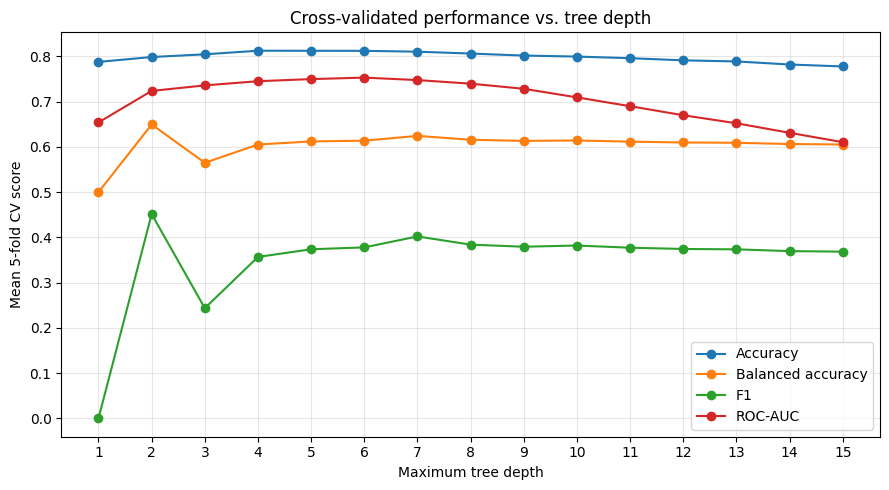

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_accuracy"],
    marker="o",
    label="Accuracy"
)

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_balanced_accuracy"],
    marker="o",
    label="Balanced accuracy"
)

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_f1"],
    marker="o",
    label="F1"
)

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_roc_auc"],
    marker="o",
    label="ROC-AUC"
)

ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("Mean 5-fold CV score")
ax.set_title("Cross-validated performance vs. tree depth")

ax.set_xticks(depth_values)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Saved: ../report/images/figure_04.png


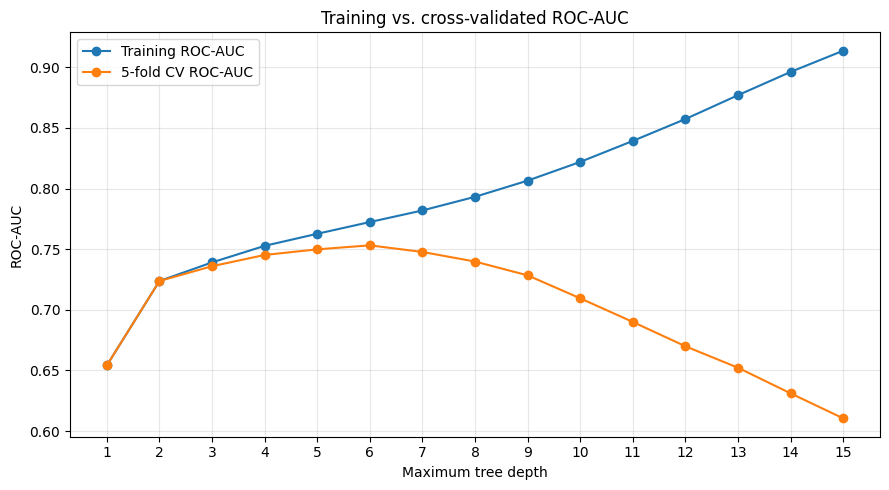

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    depth_results["max_depth"],
    depth_results["train_roc_auc"],
    marker="o",
    label="Training ROC-AUC"
)

ax.plot(
    depth_results["max_depth"],
    depth_results["cv_roc_auc"],
    marker="o",
    label="5-fold CV ROC-AUC"
)

ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("ROC-AUC")
ax.set_title("Training vs. cross-validated ROC-AUC")

ax.set_xticks(depth_values)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Saved: ../report/images/figure_05.png


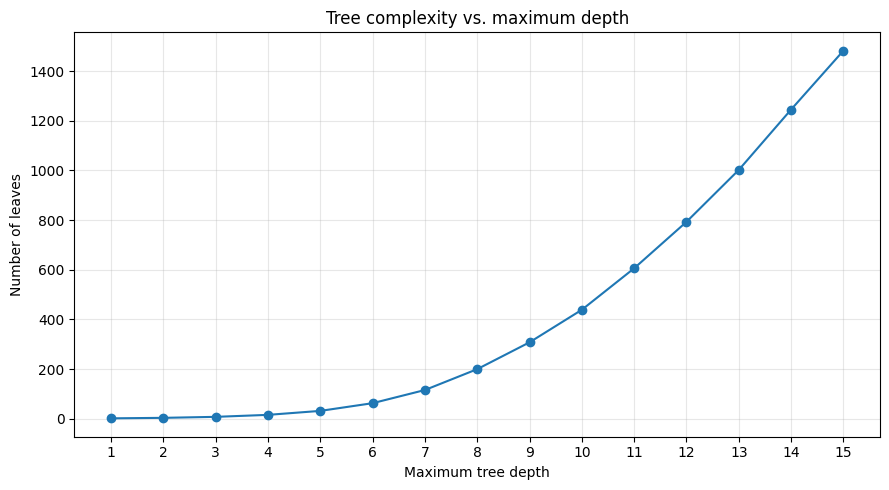

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    depth_results["max_depth"],
    depth_results["leaves"],
    marker="o"
)

ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("Number of leaves")
ax.set_title("Tree complexity vs. maximum depth")

ax.set_xticks(depth_values)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
best_auc_row = depth_results.loc[
    depth_results["cv_roc_auc"].idxmax()
]

best_balanced_acc_row = depth_results.loc[
    depth_results["cv_balanced_accuracy"].idxmax()
]

best_f1_row = depth_results.loc[
    depth_results["cv_f1"].idxmax()
]

print("Best depth by ROC-AUC:")
print(
    f"depth={int(best_auc_row['max_depth'])}, "
    f"ROC-AUC={best_auc_row['cv_roc_auc']:.4f}"
)

print("\nBest depth by balanced accuracy:")
print(
    f"depth={int(best_balanced_acc_row['max_depth'])}, "
    f"balanced accuracy="
    f"{best_balanced_acc_row['cv_balanced_accuracy']:.4f}"
)

print("\nBest depth by F1:")
print(
    f"depth={int(best_f1_row['max_depth'])}, "
    f"F1={best_f1_row['cv_f1']:.4f}"
)

Best depth by ROC-AUC:
depth=6, ROC-AUC=0.7532

Best depth by balanced accuracy:
depth=2, balanced accuracy=0.6496

Best depth by F1:
depth=2, F1=0.4515


## 4. Minimum leaf size and model complexity

Maximum depth controls how many consecutive decisions the tree can make, but
it does not directly prevent the model from creating leaves containing very
few observations.

We therefore study `min_samples_leaf`, which specifies the minimum number of
training observations that must remain in each terminal leaf.

Larger values can reduce overfitting and produce rules that apply to broader
groups of observations, potentially improving both generalization and
interpretability.

In [33]:
candidate_depths = [3, 4, 5, 6]

min_leaf_values = [
    1,
    10,
    25,
    50,
    100,
    200,
    500
]

print("Candidate depths:", candidate_depths)
print("Minimum leaf sizes:", min_leaf_values)

Candidate depths: [3, 4, 5, 6]
Minimum leaf sizes: [1, 10, 25, 50, 100, 200, 500]


In [34]:
leaf_results = []

for depth in candidate_depths:
    for min_leaf in min_leaf_values:

        model = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                (
                    "classifier",
                    DecisionTreeClassifier(
                        max_depth=depth,
                        min_samples_leaf=min_leaf,
                        random_state=RANDOM_STATE
                    )
                )
            ]
        )

        scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
        )

        model.fit(X, y)

        fitted_tree = model.named_steps["classifier"]

        leaf_results.append({
            "max_depth": depth,
            "min_samples_leaf": min_leaf,

            "train_accuracy":
                scores["train_accuracy"].mean(),
            "cv_accuracy":
                scores["test_accuracy"].mean(),

            "train_balanced_accuracy":
                scores["train_balanced_accuracy"].mean(),
            "cv_balanced_accuracy":
                scores["test_balanced_accuracy"].mean(),

            "train_f1":
                scores["train_f1"].mean(),
            "cv_f1":
                scores["test_f1"].mean(),

            "train_roc_auc":
                scores["train_roc_auc"].mean(),
            "cv_roc_auc":
                scores["test_roc_auc"].mean(),

            "cv_roc_auc_std":
                scores["test_roc_auc"].std(),

            "actual_depth":
                fitted_tree.get_depth(),
            "leaves":
                fitted_tree.get_n_leaves(),
            "nodes":
                fitted_tree.tree_.node_count
        })

leaf_results = pd.DataFrame(leaf_results)

In [35]:
leaf_results[
    [
        "max_depth",
        "min_samples_leaf",
        "cv_accuracy",
        "cv_balanced_accuracy",
        "cv_f1",
        "cv_roc_auc",
        "cv_roc_auc_std",
        "actual_depth",
        "leaves",
        "nodes"
    ]
].sort_values(
    "cv_roc_auc",
    ascending=False
).round(4)

,max_depth,min_samples_leaf,cv_accuracy,cv_balanced_accuracy,cv_f1,cv_roc_auc,cv_roc_auc_std,actual_depth,leaves,nodes
25,6,100,0.8118,0.6091,0.3664,0.7573,0.0057,6,44,87
24,6,50,0.8114,0.6126,0.3753,0.7558,0.0063,6,46,91
26,6,200,0.8151,0.6163,0.3834,0.7558,0.0039,6,34,67
23,6,25,0.8107,0.6144,0.3800,0.7541,0.0054,6,55,109
22,6,10,0.8115,0.6139,0.3784,0.7538,0.0035,6,61,121
18,5,100,0.8120,0.6097,0.3677,0.7536,0.0050,5,28,55
19,5,200,0.8137,0.6084,0.3642,0.7532,0.0051,5,24,47
27,6,500,0.8133,0.6068,0.3598,0.7532,0.0035,6,23,45
21,6,1,0.8123,0.6138,0.3779,0.7532,0.0044,6,63,125
17,5,50,0.8123,0.6121,0.3736,0.7524,0.0054,5,30,59


In [36]:
auc_matrix = leaf_results.pivot(
    index="min_samples_leaf",
    columns="max_depth",
    values="cv_roc_auc"
)

auc_matrix.round(4)

max_depth,3,4,5,6
min_samples_leaf,,,,
1,0.7359,0.7452,0.7498,0.7532
10,0.7359,0.7452,0.7499,0.7538
25,0.7359,0.7449,0.7509,0.7541
50,0.7361,0.7462,0.7524,0.7558
100,0.7354,0.7470,0.7536,0.7573
200,0.7355,0.7465,0.7532,0.7558
500,0.7374,0.7462,0.7522,0.7532


Saved: ../report/images/figure_06.png


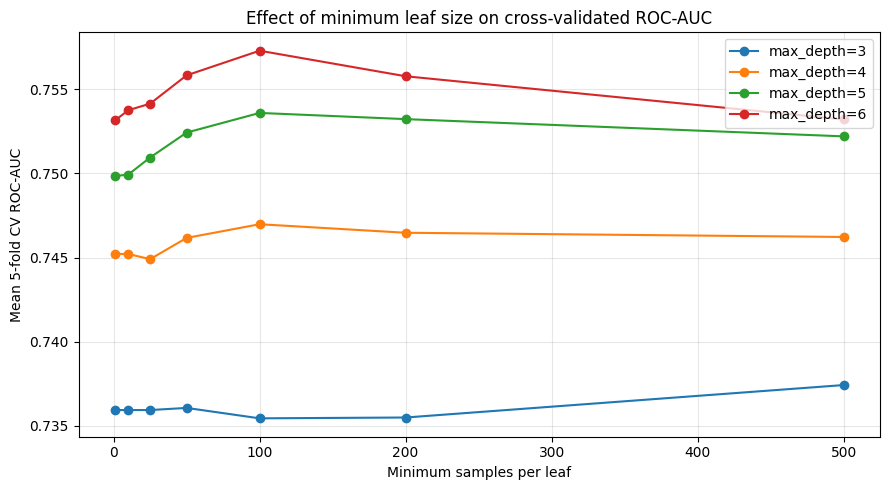

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))

for depth in candidate_depths:
    subset = leaf_results[
        leaf_results["max_depth"] == depth
    ]

    ax.plot(
        subset["min_samples_leaf"],
        subset["cv_roc_auc"],
        marker="o",
        label=f"max_depth={depth}"
    )

ax.set_xlabel("Minimum samples per leaf")
ax.set_ylabel("Mean 5-fold CV ROC-AUC")
ax.set_title(
    "Effect of minimum leaf size on cross-validated ROC-AUC"
)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
top_models = (
    leaf_results[
        [
            "max_depth",
            "min_samples_leaf",
            "cv_accuracy",
            "cv_balanced_accuracy",
            "cv_f1",
            "cv_roc_auc",
            "cv_roc_auc_std",
            "leaves",
            "nodes"
        ]
    ]
    .sort_values(
        "cv_roc_auc",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

top_models.round(4)

,max_depth,min_samples_leaf,cv_accuracy,cv_balanced_accuracy,cv_f1,cv_roc_auc,cv_roc_auc_std,leaves,nodes
0,6,100,0.8118,0.6091,0.3664,0.7573,0.0057,44,87
1,6,50,0.8114,0.6126,0.3753,0.7558,0.0063,46,91
2,6,200,0.8151,0.6163,0.3834,0.7558,0.0039,34,67
3,6,25,0.8107,0.6144,0.3800,0.7541,0.0054,55,109
4,6,10,0.8115,0.6139,0.3784,0.7538,0.0035,61,121
5,5,100,0.8120,0.6097,0.3677,0.7536,0.0050,28,55
6,5,200,0.8137,0.6084,0.3642,0.7532,0.0051,24,47
7,6,500,0.8133,0.6068,0.3598,0.7532,0.0035,23,45
8,6,1,0.8123,0.6138,0.3779,0.7532,0.0044,63,125
9,5,50,0.8123,0.6121,0.3736,0.7524,0.0054,30,59


## 5. Feature selection and final logical model

The complexity analysis showed that the highest mean cross-validated ROC-AUC
was obtained with `max_depth=6` and `min_samples_leaf=100`.

However, a minimum leaf size of 200 achieved a very similar ROC-AUC while
producing a smaller tree. It also achieved higher cross-validated balanced
accuracy and F1 score, with lower variability in ROC-AUC across folds.

Therefore, the complexity of the logical model is fixed at:

- `max_depth = 6`
- `min_samples_leaf = 200`

With the complexity fixed, we now check whether all 15 predictors are actually
needed, or whether a smaller subset can match the full model.


### 5.1 Feature selection via cross-validation

We use forward selection, starting from an empty set. At each step, the predictor
that most improves the mean cross-validated ROC-AUC is added. Each candidate is
evaluated using the same stratified five-fold cross-validation strategy, and the
preprocessor is fitted independently within each training fold to avoid fitting
the model or preprocessing steps on validation data.

The search stops at the smallest number of predictors whose mean ROC-AUC is
within one standard error of the best value. A reduced subset is preferred when
its predictive performance is comparable to that of larger subsets, since a
tree that relies on fewer variables is generally easier to read and explain.
Interpretability is not guaranteed by a smaller feature count alone, but fewer
predictors reduce the number of variables involved in the learned decision rules.

Because the same cross-validation results are used both to guide feature
selection and to estimate the performance of the selected subset, the reported
cross-validated performance may be mildly optimistic. A nested cross-validation
procedure would provide a less biased estimate of the complete feature-selection
procedure, but was not considered necessary for this preliminary analysis.

Also, because some predictors are correlated
(`latest_repayment_status` and `payment_to_bill_ratio_6m`, for example), the
exact selected subset should not be interpreted as unique.

In [39]:
FINAL_MAX_DEPTH = 6
FINAL_MIN_SAMPLES_LEAF = 200


def make_preprocessor(columns):
    selected_cat = [c for c in categorical_features if c in columns]

    transformers = []

    if selected_cat:
        transformers.append(
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                selected_cat
            )
        )

    return ColumnTransformer(
        transformers,
        remainder="passthrough",
        verbose_feature_names_out=False
    )


def cv_roc_auc(columns):
    model = Pipeline(
        steps=[
            ("preprocessor", make_preprocessor(columns)),
            (
                "classifier",
                DecisionTreeClassifier(
                    max_depth=FINAL_MAX_DEPTH,
                    min_samples_leaf=FINAL_MIN_SAMPLES_LEAF,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

    scores = cross_validate(
        model,
        X[columns],
        y,
        cv=cv,
        scoring=["roc_auc"],
        n_jobs=-1
    )

    auc = scores["test_roc_auc"]

    return auc.mean(), auc.std() / np.sqrt(cv.n_splits)


selected_features = []
remaining_features = list(X.columns)
forward_results = []

while remaining_features:
    scored = [
        (cv_roc_auc(selected_features + [feature]), feature)
        for feature in remaining_features
    ]

    (mean_auc, se_auc), best_feature = max(
        scored,
        key=lambda item: item[0][0]
    )

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)

    forward_results.append({
        "n_features": len(selected_features),
        "added_feature": best_feature,
        "cv_roc_auc": mean_auc,
        "cv_roc_auc_se": se_auc
    })

forward_results = pd.DataFrame(forward_results)

forward_results.round(4)


,n_features,added_feature,cv_roc_auc,cv_roc_auc_se
0,1,payment_to_bill_ratio_6m,0.6945,0.0025
1,2,latest_repayment_status,0.7436,0.0020
2,3,repayment_assistance_plan,0.7530,0.0027
3,4,age,0.7584,0.0018
4,5,delayed_months_6m,0.7591,0.0029
5,6,maximum_repayment_delay_6m,0.7591,0.0029
6,7,sex,0.7590,0.0029
7,8,education,0.7589,0.0033
8,9,zero_payment_months_6m,0.7590,0.0024
9,10,marital_status,0.7591,0.0023


Full model (15 predictors) mean ROC-AUC = 0.7558 (SE 0.0017), 
Best mean CV ROC-AUC: 0.7591 (SE 0.0023)
One-SE cutoff:        0.7568
Selected predictors:  4
Selected features:    ['payment_to_bill_ratio_6m', 'latest_repayment_status', 'repayment_assistance_plan', 'age']
Saved: ../report/images/figure_07.png


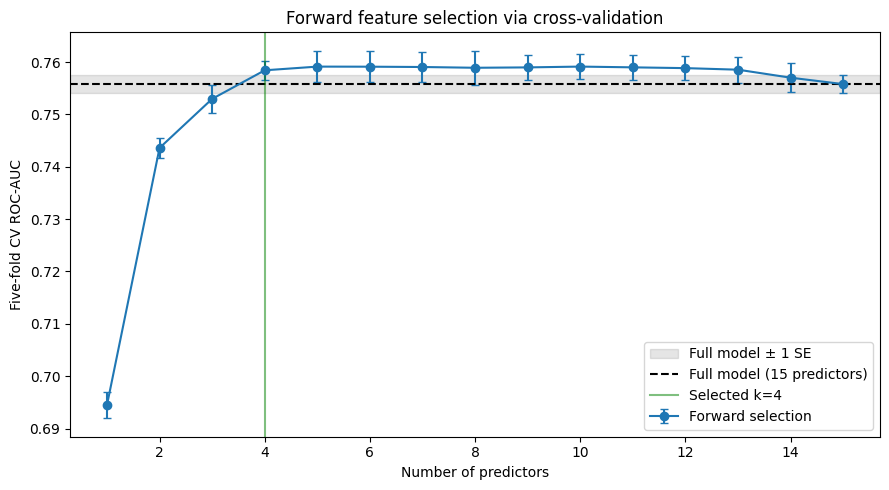

In [40]:
best_idx = forward_results["cv_roc_auc"].idxmax()
best_auc = forward_results.loc[best_idx, "cv_roc_auc"]
best_se = forward_results.loc[best_idx, "cv_roc_auc_se"]
cutoff = best_auc - best_se

within_one_se = forward_results[
    forward_results["cv_roc_auc"] >= cutoff
]

k_star = int(within_one_se["n_features"].min())

SELECTED_FEATURES = forward_results.loc[
    :k_star - 1,
    "added_feature"
].tolist()

full_auc = forward_results.iloc[-1]["cv_roc_auc"]
full_se = forward_results.iloc[-1]["cv_roc_auc_se"]

print(f"Full model (15 predictors) mean ROC-AUC = {full_auc:.4f} (SE {full_se:.4f}), ")
print(f"Best mean CV ROC-AUC: {best_auc:.4f} (SE {best_se:.4f})")
print(f"One-SE cutoff:        {cutoff:.4f}")
print(f"Selected predictors:  {k_star}")
print(f"Selected features:    {SELECTED_FEATURES}")



fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    forward_results["n_features"],
    forward_results["cv_roc_auc"],
    yerr=forward_results["cv_roc_auc_se"],
    marker="o",
    capsize=3,
    label="Forward selection"
)

ax.axhspan(
    full_auc - full_se,
    full_auc + full_se,
    color="black",
    alpha=0.10,
    label="Full model ± 1 SE"
)

ax.axhline(
    full_auc,
    linestyle="--",
    color="black",
    label=f"Full model ({forward_results['n_features'].max()} predictors)"
)

ax.axvline(
    k_star,
    linestyle="-",
    color="green",
    alpha=0.5,
    label=f"Selected k={k_star}"
)

ax.set_xlabel("Number of predictors")
ax.set_ylabel("Five-fold CV ROC-AUC")
ax.set_title("Forward feature selection via cross-validation")
ax.legend()

plt.tight_layout()
plt.show()


### 5.2 Final logical model

The final logical model is refitted using only the predictors selected in the
previous step, keeping the complexity settings fixed above
(`max_depth = 6`, `min_samples_leaf = 200`). All subsequent results — global
interpretation, local explanations and threshold selection — refer to this
reduced model.


In [41]:
final_model = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(SELECTED_FEATURES)),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=FINAL_MAX_DEPTH,
                min_samples_leaf=FINAL_MIN_SAMPLES_LEAF,
                random_state=RANDOM_STATE
            )
        )
    ]
)

final_model.fit(X[SELECTED_FEATURES], y)

final_model


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [42]:
final_cv = cross_validate(
    final_model,
    X[SELECTED_FEATURES],
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

final_cv_results = pd.DataFrame(final_cv)

final_summary = pd.DataFrame({
    "metric": [
        "accuracy",
        "balanced_accuracy",
        "f1",
        "roc_auc"
    ],
    "train_mean": [
        final_cv_results["train_accuracy"].mean(),
        final_cv_results["train_balanced_accuracy"].mean(),
        final_cv_results["train_f1"].mean(),
        final_cv_results["train_roc_auc"].mean()
    ],
    "cv_mean": [
        final_cv_results["test_accuracy"].mean(),
        final_cv_results["test_balanced_accuracy"].mean(),
        final_cv_results["test_f1"].mean(),
        final_cv_results["test_roc_auc"].mean()
    ],
    "cv_std": [
        final_cv_results["test_accuracy"].std(),
        final_cv_results["test_balanced_accuracy"].std(),
        final_cv_results["test_f1"].std(),
        final_cv_results["test_roc_auc"].std()
    ]
})

final_summary.round(4)

,metric,train_mean,cv_mean,cv_std
0,accuracy,0.8107,0.8090,0.0019
1,balanced_accuracy,0.5998,0.5976,0.0085
2,f1,0.3433,0.3382,0.0213
3,roc_auc,0.7621,0.7584,0.0045


In [43]:
final_tree = final_model.named_steps["classifier"]

print(f"Tree depth:       {final_tree.get_depth()}")
print(f"Number of leaves: {final_tree.get_n_leaves()}")
print(f"Number of nodes:  {final_tree.tree_.node_count}")

Tree depth:       6
Number of leaves: 36
Number of nodes:  71


In [44]:
fitted_preprocessor = final_model.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()

print(f"Number of transformed features: {len(feature_names)}")

feature_names

Number of transformed features: 5


array(['repayment_assistance_plan_no', 'repayment_assistance_plan_yes',
       'payment_to_bill_ratio_6m', 'latest_repayment_status', 'age'],
      dtype=object)

In [45]:
feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": final_tree.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance

,feature,importance
0,latest_repayment_status,0.546911
1,payment_to_bill_ratio_6m,0.371093
2,age,0.041293
3,repayment_assistance_plan_no,0.025002
4,repayment_assistance_plan_yes,0.015701


In [46]:
used_features = feature_importance[
    feature_importance["importance"] > 0
].copy()

used_features

,feature,importance
0,latest_repayment_status,0.546911
1,payment_to_bill_ratio_6m,0.371093
2,age,0.041293
3,repayment_assistance_plan_no,0.025002
4,repayment_assistance_plan_yes,0.015701


Saved: ../report/images/figure_08.png


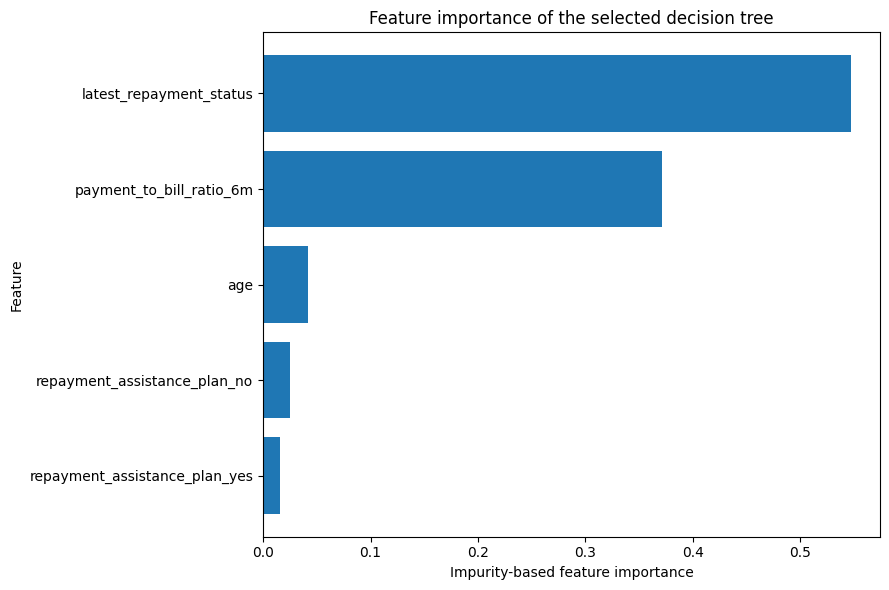

In [47]:
fig, ax = plt.subplots(figsize=(9, 6))

plot_data = used_features.sort_values(
    "importance",
    ascending=True
)

ax.barh(
    plot_data["feature"],
    plot_data["importance"]
)

ax.set_xlabel("Impurity-based feature importance")
ax.set_ylabel("Feature")
ax.set_title("Feature importance of the selected decision tree")

plt.tight_layout()
plt.show()

Saved: ../report/images/figure_09.png


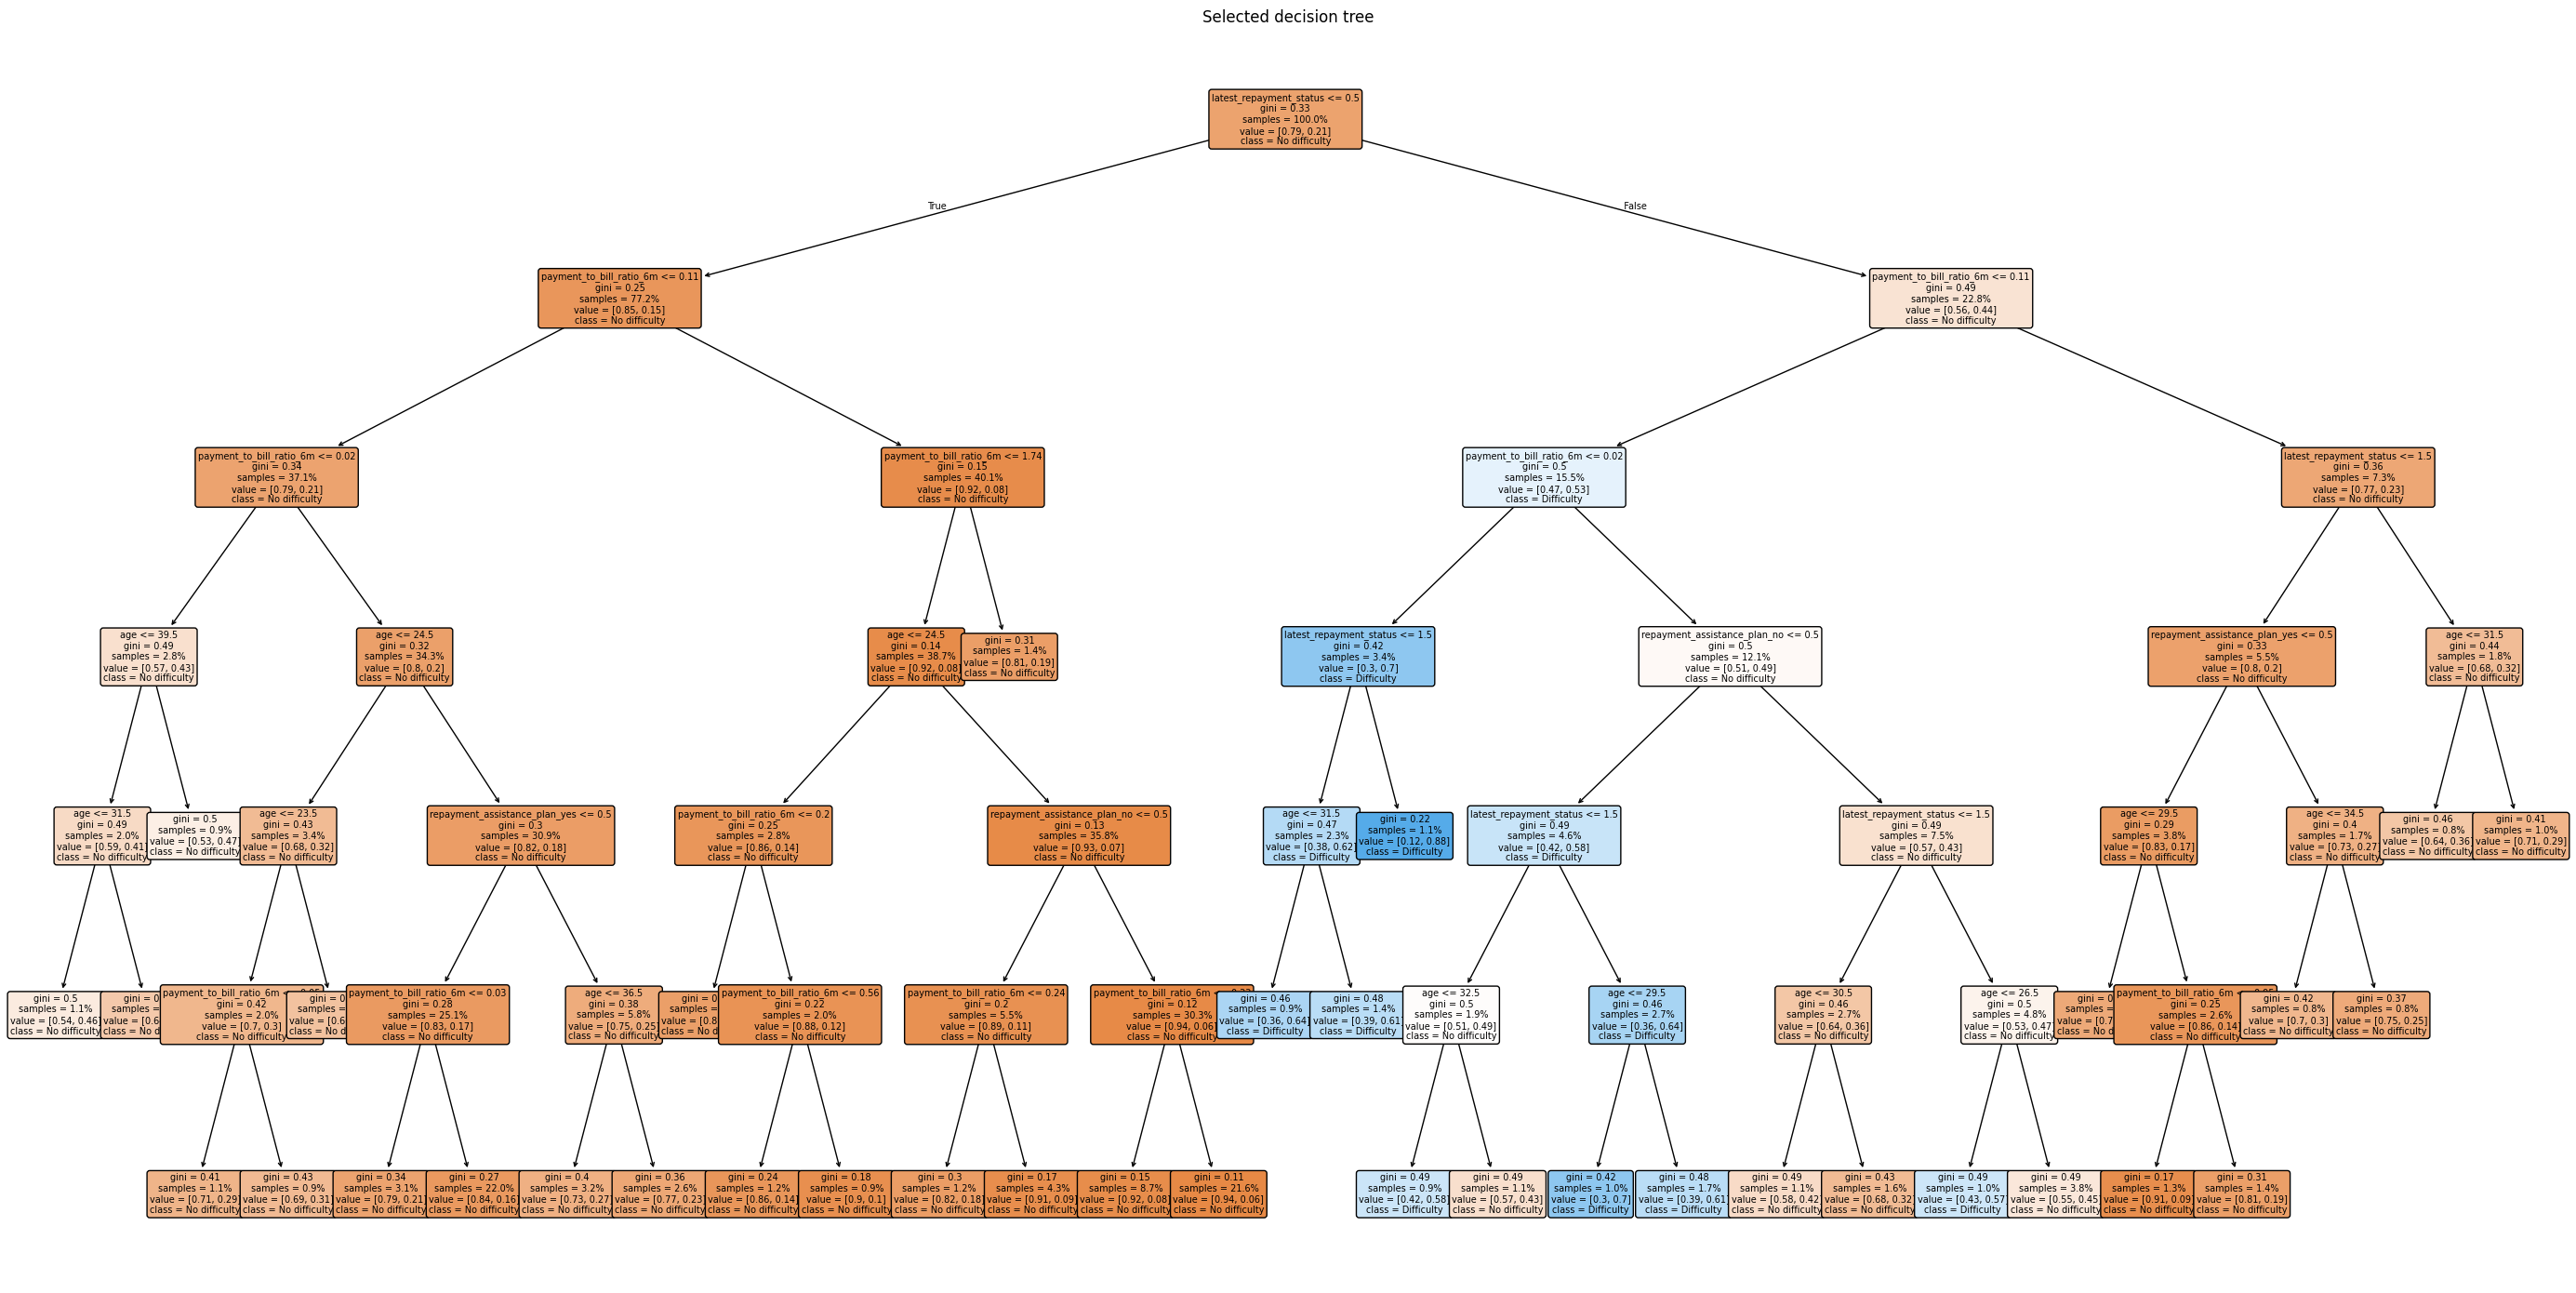

In [48]:
fig, ax = plt.subplots(figsize=(28, 14))

plot_tree(
    final_tree,
    feature_names=feature_names,
    class_names=[
        "No difficulty",
        "Difficulty"
    ],
    filled=True,
    rounded=True,
    proportion=True,
    precision=2,
    fontsize=7,
    ax=ax
)

plt.title("Selected decision tree")

plt.tight_layout()
plt.show()

Saved: ../report/images/figure_10.png


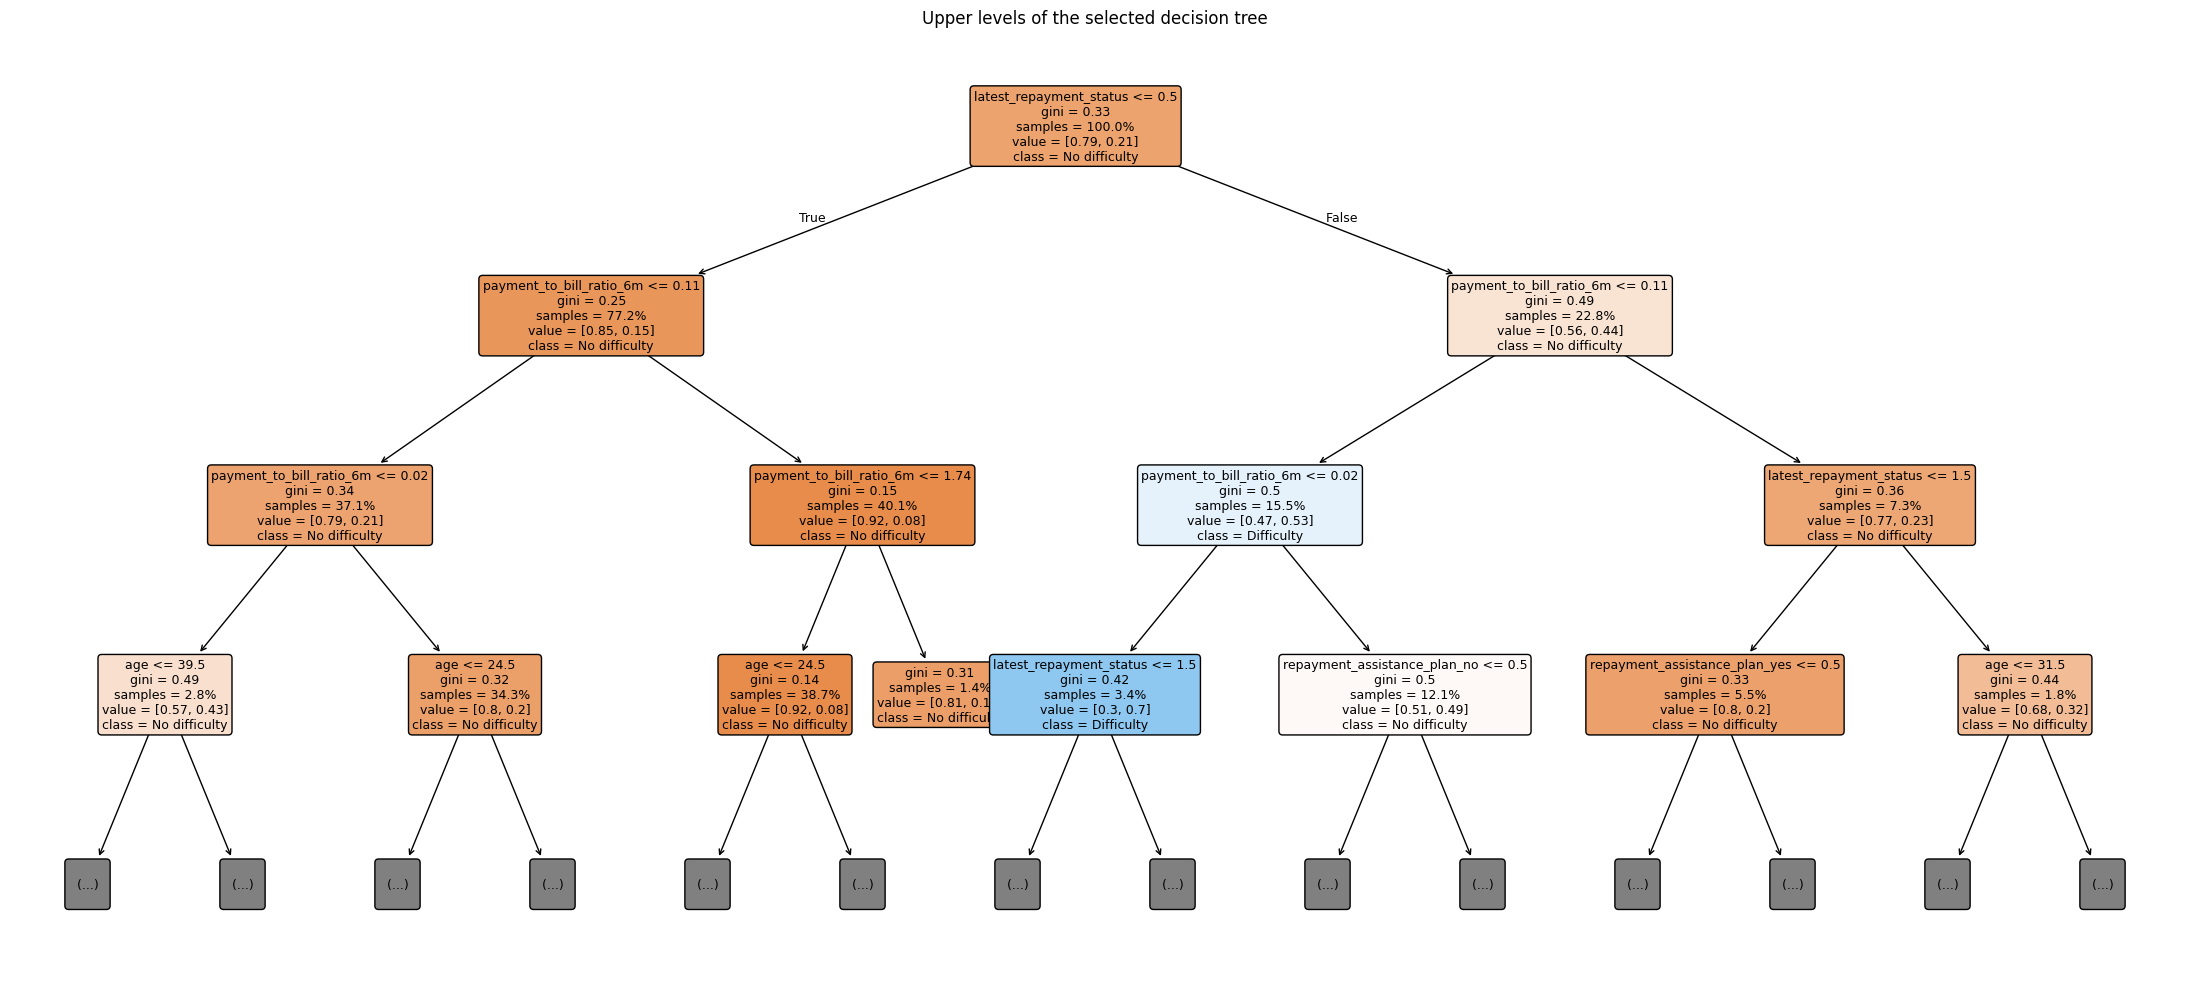

In [49]:
fig, ax = plt.subplots(figsize=(22, 10))

plot_tree(
    final_tree,
    feature_names=feature_names,
    class_names=[
        "No difficulty",
        "Difficulty"
    ],
    filled=True,
    rounded=True,
    proportion=True,
    precision=2,
    max_depth=3,
    fontsize=9,
    ax=ax
)

plt.title("Upper levels of the selected decision tree")

plt.tight_layout()
plt.show()

In [50]:
tree_rules = export_text(
    final_tree,
    feature_names=list(feature_names),
    decimals=3
)

print(tree_rules)

|--- latest_repayment_status <= 0.500
|   |--- payment_to_bill_ratio_6m <= 0.105
|   |   |--- payment_to_bill_ratio_6m <= 0.025
|   |   |   |--- age <= 39.500
|   |   |   |   |--- age <= 31.500
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- age >  31.500
|   |   |   |   |   |--- class: 0
|   |   |   |--- age >  39.500
|   |   |   |   |--- class: 0
|   |   |--- payment_to_bill_ratio_6m >  0.025
|   |   |   |--- age <= 24.500
|   |   |   |   |--- age <= 23.500
|   |   |   |   |   |--- payment_to_bill_ratio_6m <= 0.055
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- payment_to_bill_ratio_6m >  0.055
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- age >  23.500
|   |   |   |   |   |--- class: 0
|   |   |   |--- age >  24.500
|   |   |   |   |--- repayment_assistance_plan_yes <= 0.500
|   |   |   |   |   |--- payment_to_bill_ratio_6m <= 0.035
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- payment_to_bill_ratio_6m >  0.035
|   |   |   |   |  

In [51]:
tree_structure = final_tree.tree_

leaf_nodes = np.where(
    tree_structure.children_left == tree_structure.children_right
)[0]

leaf_data = []

for node_id in leaf_nodes:
    class_counts = tree_structure.value[node_id][0]
    total = class_counts.sum()

    probability_class_1 = (
        class_counts[1] / total
        if total > 0
        else 0
    )

    leaf_data.append({
        "node_id": node_id,
        "samples": tree_structure.n_node_samples[node_id],
        "class_0": class_counts[0],
        "class_1": class_counts[1],
        "probability_class_1": probability_class_1,
        "predicted_class": int(np.argmax(class_counts))
    })

leaf_summary = (
    pd.DataFrame(leaf_data)
    .sort_values(
        "probability_class_1",
        ascending=False
    )
    .reset_index(drop=True)
)

leaf_summary.round(4)

,node_id,samples,class_0,class_1,probability_class_1,predicted_class
0,42,272,0.1250,0.8750,0.8750,1
1,49,257,0.2996,0.7004,0.7004,1
2,40,214,0.3645,0.6355,0.6355,1
3,41,361,0.3934,0.6066,0.6066,1
4,50,414,0.3937,0.6063,0.6063,1
5,46,217,0.4240,0.5760,0.5760,1
6,56,255,0.4275,0.5725,0.5725,1
7,7,217,0.5346,0.4654,0.4654,0
8,5,265,0.5434,0.4566,0.4566,0
9,57,947,0.5523,0.4477,0.4477,0


In [52]:
leaf_summary.head(10).round(4)

,node_id,samples,class_0,class_1,probability_class_1,predicted_class
0,42,272,0.1250,0.8750,0.8750,1
1,49,257,0.2996,0.7004,0.7004,1
2,40,214,0.3645,0.6355,0.6355,1
3,41,361,0.3934,0.6066,0.6066,1
4,50,414,0.3937,0.6063,0.6063,1
5,46,217,0.4240,0.5760,0.5760,1
6,56,255,0.4275,0.5725,0.5725,1
7,7,217,0.5346,0.4654,0.4654,0
8,5,265,0.5434,0.4566,0.4566,0
9,57,947,0.5523,0.4477,0.4477,0


In [53]:
leaf_summary.tail(10).sort_values(
    "probability_class_1"
).round(4)

,node_id,samples,class_0,class_1,probability_class_1,predicted_class
35,34,5411,0.9433,0.0567,0.0567,0
34,33,2172,0.9157,0.0843,0.0843,0
33,63,319,0.9091,0.0909,0.0909,0
32,31,1069,0.9065,0.0935,0.0935,0
31,27,214,0.9019,0.0981,0.0981,0
30,26,289,0.8581,0.1419,0.1419,0
29,17,5488,0.8389,0.1611,0.1611,0
28,30,301,0.8173,0.1827,0.1827,0
27,35,362,0.8122,0.1878,0.1878,0
26,24,209,0.8086,0.1914,0.1914,0


In [54]:
def get_leaf_rule(tree, feature_names, target_node):
    """
    Devuelve la secuencia de decisiones desde la raíz
    hasta una hoja concreta.
    """

    tree_structure = tree.tree_
    path = []

    def recurse(node_id, current_path):
        if node_id == target_node:
            path.extend(current_path)
            return True

        left_child = tree_structure.children_left[node_id]
        right_child = tree_structure.children_right[node_id]

        # Si estamos en una hoja, no podemos continuar
        if left_child == right_child:
            return False

        feature = feature_names[
            tree_structure.feature[node_id]
        ]
        threshold = tree_structure.threshold[node_id]

        # Buscar por la rama izquierda
        if recurse(
            left_child,
            current_path + [
                f"{feature} <= {threshold:.3f}"
            ]
        ):
            return True

        # Buscar por la rama derecha
        if recurse(
            right_child,
            current_path + [
                f"{feature} > {threshold:.3f}"
            ]
        ):
            return True

        return False

    recurse(0, [])

    return path

In [55]:
highest_risk_leaf = int(
    leaf_summary.iloc[0]["node_id"]
)

highest_risk_rule = get_leaf_rule(
    final_tree,
    feature_names,
    highest_risk_leaf
)

print(
    f"Highest-risk leaf: "
    f"{highest_risk_leaf}"
)

print(
    f"Estimated probability of class 1: "
    f"{leaf_summary.iloc[0]['probability_class_1']:.3f}"
)

print(
    f"Training samples in leaf: "
    f"{int(leaf_summary.iloc[0]['samples'])}"
)

print("\nRule:")

for condition in highest_risk_rule:
    print(f"  {condition}")

Highest-risk leaf: 42
Estimated probability of class 1: 0.875
Training samples in leaf: 272

Rule:
  latest_repayment_status > 0.500
  payment_to_bill_ratio_6m <= 0.105
  payment_to_bill_ratio_6m <= 0.025
  latest_repayment_status > 1.500


In [56]:
lowest_risk_leaf = int(
    leaf_summary.iloc[-1]["node_id"]
)

lowest_risk_rule = get_leaf_rule(
    final_tree,
    feature_names,
    lowest_risk_leaf
)

print(
    f"Lowest-risk leaf: "
    f"{lowest_risk_leaf}"
)

print(
    f"Estimated probability of class 1: "
    f"{leaf_summary.iloc[-1]['probability_class_1']:.3f}"
)

print(
    f"Training samples in leaf: "
    f"{int(leaf_summary.iloc[-1]['samples'])}"
)

print("\nRule:")

for condition in lowest_risk_rule:
    print(f"  {condition}")

Lowest-risk leaf: 34
Estimated probability of class 1: 0.057
Training samples in leaf: 5411

Rule:
  latest_repayment_status <= 0.500
  payment_to_bill_ratio_6m > 0.105
  payment_to_bill_ratio_6m <= 1.735
  age > 24.500
  repayment_assistance_plan_no > 0.500
  payment_to_bill_ratio_6m > 0.325


Saved: ../report/images/figure_11.png


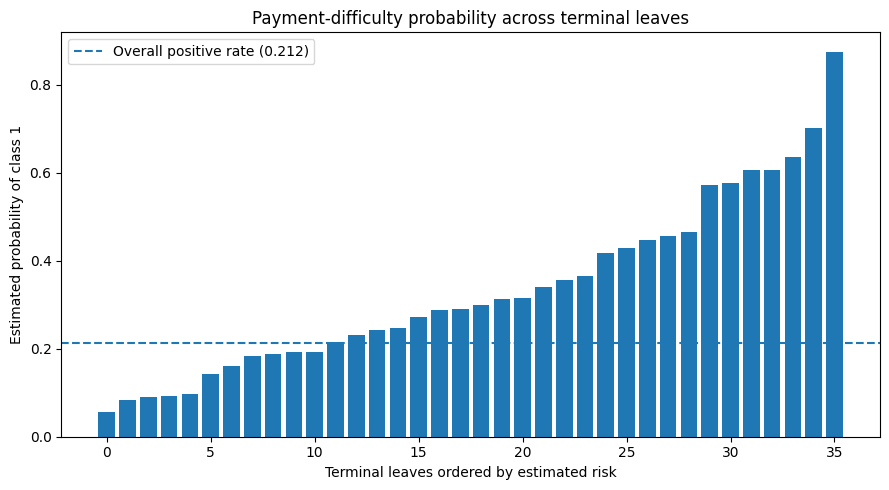

In [57]:
fig, ax = plt.subplots(figsize=(9, 5))

plot_leaf_data = leaf_summary.sort_values(
    "probability_class_1"
).reset_index(drop=True)

ax.bar(
    range(len(plot_leaf_data)),
    plot_leaf_data["probability_class_1"]
)

ax.axhline(
    y=y.mean(),
    linestyle="--",
    label=f"Overall positive rate ({y.mean():.3f})"
)

ax.set_xlabel("Terminal leaves ordered by estimated risk")
ax.set_ylabel("Estimated probability of class 1")
ax.set_title(
    "Payment-difficulty probability across terminal leaves"
)

ax.legend()

plt.tight_layout()
plt.show()

### 5.3 Optimal Sparse Decision Tree (GOSDT)

The previous model is based on CART, which constructs a decision tree using a
greedy top-down procedure. Although restricting its depth and minimum leaf size
reduces overfitting and improves interpretability, the resulting tree is not
guaranteed to be globally optimal.

As an additional logical model, we evaluate the Generalized Optimal Sparse
Decision Tree (GOSDT). GOSDT searches for a sparse decision tree by jointly
considering predictive error and model complexity rather than greedily selecting
one split at a time.

The objective is not simply to obtain higher predictive performance, but to
investigate whether a globally optimized sparse tree can provide a more compact
and interpretable alternative to the CART model.

In [58]:
from gosdt import GOSDTClassifier, ThresholdGuessBinarizer
from sklearn.ensemble import GradientBoostingClassifier
import time

GOSDT_REGULARIZATION_GRID = [
    0.0005,
    0.001,
    0.005,
    0.01
]

GOSDT_DEPTH_BUDGET = 6
GOSDT_TIME_LIMIT = 120

In [59]:
X_gosdt = X[SELECTED_FEATURES].copy()
y_gosdt = y.copy()

print("Original shape:", X_gosdt.shape)

Original shape: (25000, 4)


#### 5.3.1 Regularization selection

The GOSDT regularization parameter controls the trade-off between predictive
error and tree complexity. Larger values penalize additional leaves more
strongly and therefore favor smaller trees.

We select the regularization parameter using the same stratified five-fold
cross-validation strategy. All preprocessing, threshold generation, and
reference-model fitting are performed independently within each training fold
to avoid information leakage.

Balanced accuracy is used as the selection criterion because the target is
imbalanced and accuracy alone may favor the majority class.

In [60]:
gosdt_reg_results = []

for regularization in GOSDT_REGULARIZATION_GRID:

    fold_scores = []

    print(f"Regularization = {regularization}")

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(X_gosdt, y_gosdt),
        start=1
    ):
        X_train_fold = X_gosdt.iloc[train_idx]
        X_val_fold = X_gosdt.iloc[val_idx]

        y_train_fold = y_gosdt.iloc[train_idx]
        y_val_fold = y_gosdt.iloc[val_idx]

        # Preprocessing
        fold_preprocessor = make_preprocessor(SELECTED_FEATURES)

        X_train_encoded = fold_preprocessor.fit_transform(
            X_train_fold
        )
        X_val_encoded = fold_preprocessor.transform(
            X_val_fold
        )

        feature_names = fold_preprocessor.get_feature_names_out()

        X_train_encoded = pd.DataFrame(
            X_train_encoded,
            columns=feature_names,
            index=X_train_fold.index
        )

        X_val_encoded = pd.DataFrame(
            X_val_encoded,
            columns=feature_names,
            index=X_val_fold.index
        )

        # Threshold generation
        fold_binarizer = ThresholdGuessBinarizer(
            n_estimators=40,
            max_depth=1,
            random_state=RANDOM_STATE
        )

        fold_binarizer.set_output(transform="pandas")

        X_train_binary = fold_binarizer.fit_transform(
            X_train_encoded,
            y_train_fold
        )

        X_val_binary = fold_binarizer.transform(
            X_val_encoded
        )

        # Reference model
        fold_reference = GradientBoostingClassifier(
            n_estimators=40,
            max_depth=1,
            random_state=RANDOM_STATE
        )

        fold_reference.fit(
            X_train_binary,
            y_train_fold
        )

        reference_labels_fold = fold_reference.predict(
            X_train_binary
        )

        # GOSDT
        fold_model = GOSDTClassifier(
            regularization=regularization,
            depth_budget=GOSDT_DEPTH_BUDGET,
            time_limit=GOSDT_TIME_LIMIT,
            similar_support=False,
            verbose=False
        )

        fold_model.fit(
            X_train_binary,
            y_train_fold,
            y_ref=reference_labels_fold
        )

        y_pred = np.asarray(
            fold_model.predict(X_val_binary)
        ).reshape(-1)

        fold_scores.append({
            "balanced_accuracy":
                balanced_accuracy_score(y_val_fold, y_pred),
            "f1":
                f1_score(y_val_fold, y_pred),
            "accuracy":
                accuracy_score(y_val_fold, y_pred)
        })

    fold_scores = pd.DataFrame(fold_scores)

    gosdt_reg_results.append({
        "regularization": regularization,
        "accuracy_mean": fold_scores["accuracy"].mean(),
        "balanced_accuracy_mean":
            fold_scores["balanced_accuracy"].mean(),
        "f1_mean": fold_scores["f1"].mean(),
        "balanced_accuracy_std":
            fold_scores["balanced_accuracy"].std()
    })

gosdt_reg_results = pd.DataFrame(gosdt_reg_results)

display(
    gosdt_reg_results
    .sort_values("balanced_accuracy_mean", ascending=False)
    .round(4)
)

Regularization = 0.0005
Regularization = 0.001
Regularization = 0.005
Regularization = 0.01


,regularization,accuracy_mean,balanced_accuracy_mean,f1_mean,balanced_accuracy_std
1,0.0010,0.8083,0.6061,0.3605,0.0032
0,0.0005,0.8091,0.5972,0.3369,0.0081
2,0.0050,0.7973,0.5763,0.2815,0.0284
3,0.0100,0.7893,0.5118,0.0471,0.0264


In [61]:
best_gosdt_row = gosdt_reg_results.loc[
    gosdt_reg_results["balanced_accuracy_mean"].idxmax()
]

GOSDT_REGULARIZATION = float(
    best_gosdt_row["regularization"]
)

print(
    f"Selected regularization: "
    f"{GOSDT_REGULARIZATION}"
)

print(
    f"Mean CV balanced accuracy: "
    f"{best_gosdt_row['balanced_accuracy_mean']:.4f}"
)

Selected regularization: 0.001
Mean CV balanced accuracy: 0.6061


In [62]:
gosdt_preprocessor = make_preprocessor(SELECTED_FEATURES)

X_gosdt_encoded = gosdt_preprocessor.fit_transform(X_gosdt)

X_gosdt_encoded = pd.DataFrame(
    X_gosdt_encoded,
    columns=gosdt_preprocessor.get_feature_names_out(),
    index=X_gosdt.index
)

print("Original shape:", X_gosdt.shape)
print("Encoded shape:", X_gosdt_encoded.shape)

Original shape: (25000, 4)
Encoded shape: (25000, 5)


In [63]:
threshold_binarizer = ThresholdGuessBinarizer(
    n_estimators=40,
    max_depth=1,
    random_state=RANDOM_STATE
)

threshold_binarizer.set_output(transform="pandas")

X_gosdt_binary = threshold_binarizer.fit_transform(
    X_gosdt_encoded,
    y_gosdt
)

print("Encoded shape:", X_gosdt_encoded.shape)
print("Binarized shape:", X_gosdt_binary.shape)

display(X_gosdt_binary.head())

Encoded shape: (25000, 5)
Binarized shape: (25000, 11)


,repayment_assistance_plan_no <= 0.5,payment_to_bill_ratio_6m <= 0.024999999441206455,payment_to_bill_ratio_6m <= 0.03499999921768904,payment_to_bill_ratio_6m <= 0.0950000025331974,payment_to_bill_ratio_6m <= 0.10500000044703484,payment_to_bill_ratio_6m <= 0.11499999836087227,payment_to_bill_ratio_6m <= 0.13499999791383743,latest_repayment_status <= 0.5,latest_repayment_status <= 1.5,age <= 24.5,latest_repayment_status <= 2.5
0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
1,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
4,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0


In [64]:
print(X_gosdt_encoded.dtypes)
print(
    "All columns numeric:",
    all(pd.api.types.is_numeric_dtype(dtype)
        for dtype in X_gosdt_encoded.dtypes)
)

repayment_assistance_plan_no     float64
repayment_assistance_plan_yes    float64
payment_to_bill_ratio_6m         float64
latest_repayment_status          float64
age                              float64
dtype: object
All columns numeric: True


In [65]:
reference_model = GradientBoostingClassifier(
    n_estimators=40,
    max_depth=1,
    random_state=RANDOM_STATE
)

reference_model.fit(
    X_gosdt_binary,
    y_gosdt
)

reference_labels = reference_model.predict(
    X_gosdt_binary
)

print(
    f"Reference model accuracy: "
    f"{accuracy_score(y_gosdt, reference_labels):.4f}"
)

print(
    f"Reference predicted positive rate: "
    f"{reference_labels.mean():.4f}"
)

Reference model accuracy: 0.8065
Reference predicted positive rate: 0.0467


In [66]:
gosdt_model = GOSDTClassifier(
    regularization=GOSDT_REGULARIZATION,
    depth_budget=GOSDT_DEPTH_BUDGET,
    time_limit=GOSDT_TIME_LIMIT,
    similar_support=False,
    verbose=False
)

start_time = time.perf_counter()

gosdt_model.fit(
    X_gosdt_binary,
    y_gosdt,
    y_ref=reference_labels
)

gosdt_training_time = time.perf_counter() - start_time

gosdt_predictions = np.asarray(
    gosdt_model.predict(X_gosdt_binary)
).reshape(-1)

print(f"Training time: {gosdt_training_time:.2f} seconds")
print(
    f"Training accuracy: "
    f"{accuracy_score(y_gosdt, gosdt_predictions):.4f}"
)
print(
    f"Training balanced accuracy: "
    f"{balanced_accuracy_score(y_gosdt, gosdt_predictions):.4f}"
)
print(
    f"Training F1: "
    f"{f1_score(y_gosdt, gosdt_predictions):.4f}"
)
print(
    f"Predicted positive rate: "
    f"{gosdt_predictions.mean():.4f}"
)

Training time: 0.15 seconds
Training accuracy: 0.8103
Training balanced accuracy: 0.6111
Training F1: 0.3722
Predicted positive rate: 0.0901


In [67]:
print(gosdt_model.trees_[0])

<class 'gosdt._tree.Tree'>: { feature: 6 [ left child: { feature: 5 [ left child: { feature: 7 [ left child: { prediction: 0, loss: 0.0809599980711937 }, right child: { feature: 0 [ left child: { prediction: 1, loss: 0.02223999984562397 }, right child: { feature: 9 [ left child: { prediction: 1, loss: 0.004119999706745148 }, right child: { feature: 1 [ left child: { prediction: 1, loss: 0.007479999680072069 }, right child: { prediction: 0, loss: 0.027559999376535416 }] }] }] }] }, right child: { prediction: 0, loss: 0.002959999954327941 }] }, right child: { prediction: 0, loss: 0.04439999908208847 }] }, Index(['repayment_assistance_plan_no <= 0.5',
       'payment_to_bill_ratio_6m <= 0.024999999441206455',
       'payment_to_bill_ratio_6m <= 0.03499999921768904',
       'payment_to_bill_ratio_6m <= 0.0950000025331974',
       'payment_to_bill_ratio_6m <= 0.10500000044703484',
       'payment_to_bill_ratio_6m <= 0.11499999836087227',
       'payment_to_bill_ratio_6m <= 0.134999997913837

#### 5.3.2 Five-fold cross-validation

To obtain a comparable estimate of generalization performance, GOSDT is
evaluated using the same stratified five-fold cross-validation strategy used
for CART.

All preprocessing steps, including categorical encoding and threshold
generation, are fitted independently within each training fold to prevent
information leakage from the validation data.

In [68]:
gosdt_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_gosdt, y_gosdt),
    start=1
):
    print(f"Fold {fold}/5")

    X_train_fold = X_gosdt.iloc[train_idx]
    X_val_fold = X_gosdt.iloc[val_idx]

    y_train_fold = y_gosdt.iloc[train_idx]
    y_val_fold = y_gosdt.iloc[val_idx]

    # 1. Categorical preprocessing
    fold_preprocessor = make_preprocessor(SELECTED_FEATURES)

    X_train_encoded = fold_preprocessor.fit_transform(X_train_fold)
    X_val_encoded = fold_preprocessor.transform(X_val_fold)

    feature_names = fold_preprocessor.get_feature_names_out()

    X_train_encoded = pd.DataFrame(
        X_train_encoded,
        columns=feature_names,
        index=X_train_fold.index
    )

    X_val_encoded = pd.DataFrame(
        X_val_encoded,
        columns=feature_names,
        index=X_val_fold.index
    )

    # 2. Threshold generation
    fold_binarizer = ThresholdGuessBinarizer(
        n_estimators=40,
        max_depth=1,
        random_state=RANDOM_STATE
    )

    fold_binarizer.set_output(transform="pandas")

    X_train_binary = fold_binarizer.fit_transform(
        X_train_encoded,
        y_train_fold
    )

    X_val_binary = fold_binarizer.transform(
        X_val_encoded
    )

    # 3. Reference model
    fold_reference = GradientBoostingClassifier(
        n_estimators=40,
        max_depth=1,
        random_state=RANDOM_STATE
    )

    fold_reference.fit(
        X_train_binary,
        y_train_fold
    )

    reference_labels_fold = fold_reference.predict(
        X_train_binary
    )

    # 4. GOSDT
    fold_gosdt = GOSDTClassifier(
        regularization=GOSDT_REGULARIZATION,
        depth_budget=GOSDT_DEPTH_BUDGET,
        time_limit=GOSDT_TIME_LIMIT,
        similar_support=False,
        verbose=False
    )

    start_time = time.perf_counter()

    fold_gosdt.fit(
        X_train_binary,
        y_train_fold,
        y_ref=reference_labels_fold
    )

    elapsed = time.perf_counter() - start_time

    # 5. Validation predictions
    y_pred = np.asarray(
        fold_gosdt.predict(X_val_binary)
    ).reshape(-1)

    gosdt_cv_results.append({
        "fold": fold,
        "accuracy": accuracy_score(y_val_fold, y_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_val_fold, y_pred
        ),
        "f1": f1_score(y_val_fold, y_pred),
        "predicted_positive_rate": y_pred.mean(),
        "training_time": elapsed
    })

    print(
        f"  Accuracy: {gosdt_cv_results[-1]['accuracy']:.4f} | "
        f"Balanced accuracy: "
        f"{gosdt_cv_results[-1]['balanced_accuracy']:.4f} | "
        f"F1: {gosdt_cv_results[-1]['f1']:.4f} | "
        f"Time: {elapsed:.2f}s"
    )

Fold 1/5
  Accuracy: 0.8092 | Balanced accuracy: 0.6045 | F1: 0.3563 | Time: 0.09s
Fold 2/5
  Accuracy: 0.8074 | Balanced accuracy: 0.6106 | F1: 0.3718 | Time: 0.10s
Fold 3/5
  Accuracy: 0.8060 | Balanced accuracy: 0.6021 | F1: 0.3516 | Time: 0.08s
Fold 4/5
  Accuracy: 0.8090 | Balanced accuracy: 0.6075 | F1: 0.3638 | Time: 0.15s
Fold 5/5
  Accuracy: 0.8100 | Balanced accuracy: 0.6057 | F1: 0.3590 | Time: 0.15s


In [69]:
gosdt_cv_results = pd.DataFrame(gosdt_cv_results)

display(gosdt_cv_results.round(4))

,fold,accuracy,balanced_accuracy,f1,predicted_positive_rate,training_time
0,1,0.8092,0.6045,0.3563,0.0844,0.0890
1,2,0.8074,0.6106,0.3718,0.0946,0.0974
2,3,0.8060,0.6021,0.3516,0.0870,0.0814
3,4,0.8090,0.6075,0.3638,0.0880,0.1540
4,5,0.8100,0.6057,0.3590,0.0842,0.1511


In [70]:
gosdt_cv_summary = pd.DataFrame({
    "metric": [
        "accuracy",
        "balanced_accuracy",
        "f1"
    ],
    "cv_mean": [
        gosdt_cv_results["accuracy"].mean(),
        gosdt_cv_results["balanced_accuracy"].mean(),
        gosdt_cv_results["f1"].mean()
    ],
    "cv_std": [
        gosdt_cv_results["accuracy"].std(),
        gosdt_cv_results["balanced_accuracy"].std(),
        gosdt_cv_results["f1"].std()
    ]
})

display(gosdt_cv_summary.round(4))

,metric,cv_mean,cv_std
0,accuracy,0.8083,0.0016
1,balanced_accuracy,0.6061,0.0032
2,f1,0.3605,0.0077


In [71]:
logical_models_comparison = pd.DataFrame({
    "Classifier": [
        "DecisionTreeClassifier (CART)",
        "GOSDTClassifier"
    ],
    "Key settings": [
        "max_depth=6, min_samples_leaf=200",
        (
            f"regularization={GOSDT_REGULARIZATION}, "
            f"depth_budget={GOSDT_DEPTH_BUDGET}"
        )
    ],
    "Accuracy CV": [
        final_cv_results["test_accuracy"].mean(),
        gosdt_cv_results["accuracy"].mean()
    ],
    "Balanced accuracy CV": [
        final_cv_results["test_balanced_accuracy"].mean(),
        gosdt_cv_results["balanced_accuracy"].mean()
    ],
    "F1 CV": [
        final_cv_results["test_f1"].mean(),
        gosdt_cv_results["f1"].mean()
    ]
})

display(logical_models_comparison.round(4))

,Classifier,Key settings,Accuracy CV,Balanced accuracy CV,F1 CV
0,DecisionTreeClassifier (CART),"max_depth=6, min_samples_leaf=200",0.8090,0.5976,0.3382
1,GOSDTClassifier,"regularization=0.001, depth_budget=6",0.8083,0.6061,0.3605


## 6. Global Model Interpretation

Once the decision tree has been selected and trained, we analyze its global
behavior.

The interpretation is based on:

- the importance of the features used by the tree;
- the decisions made at the upper levels of the tree;
- the rules associated with the terminal leaves;
- the estimated probability of payment difficulty in each leaf.

Feature importances and decision rules describe the behavior of the learned
model. They should not be interpreted as causal relationships between the
features and payment difficulty.

## 7. Classification-threshold selection

A classifier outputs a probability, and a threshold converts that probability
into a label. The default threshold of 0.5 is only optimal when the classes are
balanced and both error types cost the same. Here the classes are imbalanced
(about 79% / 21%), and a missed payment difficulty is arguably more costly than
a false alarm.

The threshold is selected on the out-of-fold predictions. We choose the threshold that maximises balanced accuracy, which weights both classes equally.


In [72]:
from sklearn.model_selection import cross_val_predict

oof_probabilities = cross_val_predict(
    final_model,
    X[SELECTED_FEATURES],
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

oof_results = pd.DataFrame({
    "row_id": train[ID_COLUMN],
    "true_class": y.values,
    "probability_class_1": oof_probabilities
})

oof_results.head()


,row_id,true_class,probability_class_1
0,CR26-120473,0,0.159460
1,CR26-127004,0,0.160410
2,CR26-116408,0,0.056912
3,CR26-125768,0,0.226209
4,CR26-118040,0,0.271157


In [73]:
def metrics_at_threshold(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy":
            balanced_accuracy_score(y_true, predictions),
        "precision":
            precision_score(y_true, predictions, zero_division=0),
        "recall":
            recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0)
    }


threshold_grid = np.round(np.arange(0.05, 1.00, 0.01), 2)

threshold_results = pd.DataFrame(
    [
        metrics_at_threshold(y.values, oof_probabilities, threshold)
        for threshold in threshold_grid
    ]
)

best_balanced = threshold_results.loc[
    threshold_results["balanced_accuracy"].idxmax()
]

best_f1 = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

CHOSEN_THRESHOLD = float(best_balanced["threshold"])

print(
    f"Threshold maximising balanced accuracy: "
    f"{CHOSEN_THRESHOLD:.2f} "
    f"(balanced accuracy "
    f"{best_balanced['balanced_accuracy']:.4f})"
)
print(
    f"Threshold maximising F1: "
    f"{best_f1['threshold']:.2f} "
    f"(F1 {best_f1['f1']:.4f})"
)

threshold_results.round(4)


Threshold maximising balanced accuracy: 0.22 (balanced accuracy 0.6938)
Threshold maximising F1: 0.25 (F1 0.4992)


,threshold,accuracy,balanced_accuracy,precision,recall,f1
0,0.05,0.2121,0.5000,0.2121,1.0000,0.3500
1,0.06,0.4020,0.5988,0.2542,0.9406,0.4002
2,0.07,0.4020,0.5988,0.2542,0.9406,0.4002
3,0.08,0.4242,0.6086,0.2600,0.9289,0.4063
4,0.09,0.4853,0.6366,0.2789,0.8995,0.4257
...,...,...,...,...,...,...
90,0.95,0.7879,0.5000,0.0000,0.0000,0.0000
91,0.96,0.7879,0.5000,0.0000,0.0000,0.0000
92,0.97,0.7879,0.5000,0.0000,0.0000,0.0000
93,0.98,0.7879,0.5000,0.0000,0.0000,0.0000


In [74]:
fold_thresholds = []

for _, val_idx in cv.split(X[SELECTED_FEATURES], y):

    y_val = y.iloc[val_idx]
    probabilities_val = oof_probabilities[val_idx]

    balanced = [
        balanced_accuracy_score(
            y_val,
            (probabilities_val >= threshold).astype(int)
        )
        for threshold in threshold_grid
    ]

    fold_thresholds.append(
        threshold_grid[int(np.argmax(balanced))]
    )

pd.Series(
    fold_thresholds,
    name="optimal_threshold_per_fold"
)


0    0.20
1    0.22
2    0.22
3    0.23
4    0.17
Name: optimal_threshold_per_fold, dtype: float64

Saved: ../report/images/figure_12.png


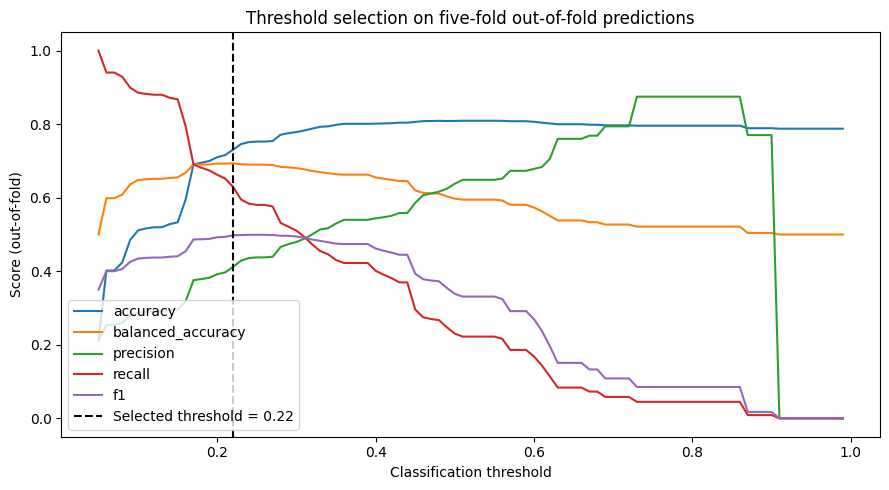

In [75]:
fig, ax = plt.subplots(figsize=(9, 5))

for metric in [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1"
]:
    ax.plot(
        threshold_results["threshold"],
        threshold_results[metric],
        label=metric
    )

ax.axvline(
    CHOSEN_THRESHOLD,
    linestyle="--",
    color="black",
    label=f"Selected threshold = {CHOSEN_THRESHOLD:.2f}"
)

ax.set_xlabel("Classification threshold")
ax.set_ylabel("Score (out-of-fold)")
ax.set_title(
    "Threshold selection on five-fold out-of-fold predictions"
)
ax.legend()

plt.tight_layout()
plt.show()


In [76]:
oof_predictions = (
    oof_probabilities >= CHOSEN_THRESHOLD
).astype(int)

oof_results["predicted_class"] = oof_predictions

oof_results.head()


,row_id,true_class,probability_class_1,predicted_class
0,CR26-120473,0,0.159460,0
1,CR26-127004,0,0.160410,0
2,CR26-116408,0,0.056912,0
3,CR26-125768,0,0.226209,1
4,CR26-118040,0,0.271157,1


## 8. Local Explanations

In addition to the global interpretation of the tree, we analyze individual
predictions.

To avoid selecting examples based only on predictions made on the same data
used to train the model, we use the out-of-fold predictions obtained above.

Two representative observations are selected:

- one observation whose true class is 0;
- one observation whose true class is 1.

These same cases will be retained for the subsequent comparison of the
explanations provided by the different models.


In [77]:
print(
    f"Accuracy:          "
    f"{accuracy_score(y, oof_predictions):.4f}"
)

print(
    f"Balanced accuracy: "
    f"{balanced_accuracy_score(y, oof_predictions):.4f}"
)

print(
    f"F1:                "
    f"{f1_score(y, oof_predictions):.4f}"
)

print(
    f"ROC-AUC:           "
    f"{roc_auc_score(y, oof_probabilities):.4f}"
)

print("\nMatriz de confusión:")
print(confusion_matrix(y, oof_predictions))

Accuracy:          0.7308
Balanced accuracy: 0.6938
F1:                0.4980
ROC-AUC:           0.7575

Matriz de confusión:
[[14933  4764]
 [ 1965  3338]]


Saved: ../report/images/figure_13.png


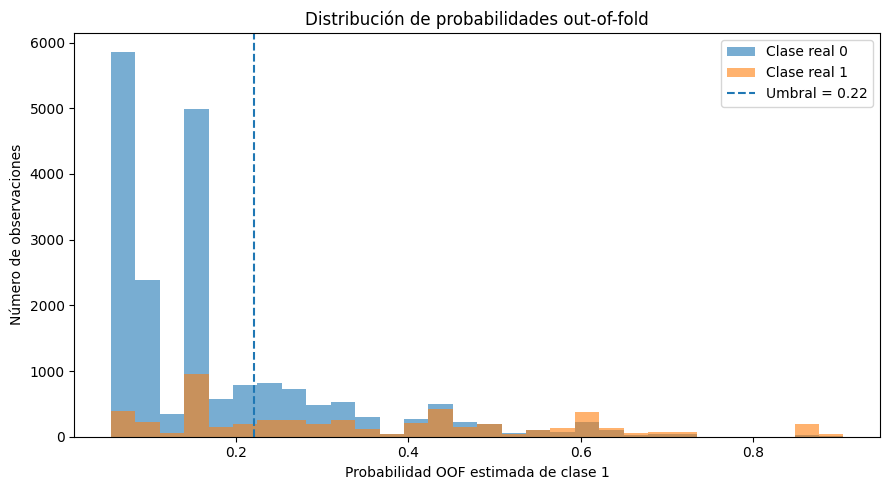

In [78]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    oof_results.loc[
        oof_results["true_class"] == 0,
        "probability_class_1"
    ],
    bins=30,
    alpha=0.6,
    label="Clase real 0"
)

ax.hist(
    oof_results.loc[
        oof_results["true_class"] == 1,
        "probability_class_1"
    ],
    bins=30,
    alpha=0.6,
    label="Clase real 1"
)

ax.axvline(
    CHOSEN_THRESHOLD,
    linestyle="--",
    label=f"Umbral = {CHOSEN_THRESHOLD:.2f}"
)

ax.set_xlabel("Probabilidad OOF estimada de clase 1")
ax.set_ylabel("Número de observaciones")
ax.set_title("Distribución de probabilidades out-of-fold")

ax.legend()

plt.tight_layout()
plt.show()

In [79]:
correct_oof = oof_results[
    oof_results["true_class"]
    == oof_results["predicted_class"]
].copy()

selected_cases = []

for target_class in [0, 1]:

    candidates = correct_oof[
        correct_oof["true_class"] == target_class
    ].copy()

    median_probability = candidates[
        "probability_class_1"
    ].median()

    candidates["distance_to_median"] = (
        candidates["probability_class_1"]
        - median_probability
    ).abs()

    selected_case = candidates.sort_values(
        "distance_to_median"
    ).iloc[0]

    selected_cases.append(selected_case)

selected_cases = pd.DataFrame(
    selected_cases
).reset_index(drop=True)

selected_cases

,row_id,true_class,probability_class_1,predicted_class,distance_to_median
0,CR26-103896,0,0.091549,0,0.0
1,CR26-108758,1,0.446115,1,0.0


In [80]:
selected_row_ids = selected_cases["row_id"].tolist()

selected_instances = train[
    train[ID_COLUMN].isin(selected_row_ids)
].copy()

selected_instances

,row_id,credit_limit,sex,education,marital_status,age,latest_repayment_status,maximum_repayment_delay_6m,delayed_months_6m,average_bill_6m,bill_change_sep_to_apr,total_payment_6m,payment_to_bill_ratio_6m,zero_payment_months_6m,utilization_sep,repayment_assistance_plan,payment_difficulty_next_month
71,CR26-103896,150000,female,university,married,39,-1,0,0,39900,-65500,198600,0.83,0,0.08,yes,0
24866,CR26-108758,70000,male,university,single,39,2,2,6,37200,-6400,12100,0.05,1,0.48,no,1


In [81]:
X_selected = selected_instances[SELECTED_FEATURES]

final_probabilities = final_model.predict_proba(
    X_selected
)[:, 1]

final_predictions = final_model.predict(
    X_selected
)

local_predictions = selected_instances[
    [ID_COLUMN, TARGET]
].copy()

local_predictions[
    "predicted_class"
] = final_predictions

local_predictions[
    "probability_class_1"
] = final_probabilities

local_predictions

,row_id,payment_difficulty_next_month,predicted_class,probability_class_1
71,CR26-103896,0,0,0.093545
24866,CR26-108758,1,0,0.447730


In [82]:
X_selected_transformed = (
    final_model
    .named_steps["preprocessor"]
    .transform(X_selected)
)

assigned_leaves = final_tree.apply(
    X_selected_transformed
)

local_predictions[
    "leaf_node"
] = assigned_leaves

local_predictions

,row_id,payment_difficulty_next_month,predicted_class,probability_class_1,leaf_node
71,CR26-103896,0,0,0.093545,31
24866,CR26-108758,1,0,0.447730,57


In [83]:
for _, row in local_predictions.iterrows():

    row_id = row[ID_COLUMN]
    leaf_node = int(row["leaf_node"])

    rule = get_leaf_rule(
        final_tree,
        feature_names,
        leaf_node
    )

    print("=" * 70)
    print(f"Observación: {row_id}")
    print(f"Clase real: {int(row[TARGET])}")
    print(
        f"Predicción: "
        f"{int(row['predicted_class'])}"
    )
    print(
        f"P(clase 1): "
        f"{row['probability_class_1']:.3f}"
    )
    print(f"Hoja: {leaf_node}")

    print("\nCamino de decisión:")

    for condition in rule:
        print(f"  {condition}")

    print()

Observación: CR26-103896
Clase real: 0
Predicción: 0
P(clase 1): 0.094
Hoja: 31

Camino de decisión:
  latest_repayment_status <= 0.500
  payment_to_bill_ratio_6m > 0.105
  payment_to_bill_ratio_6m <= 1.735
  age > 24.500
  repayment_assistance_plan_no <= 0.500
  payment_to_bill_ratio_6m > 0.245

Observación: CR26-108758
Clase real: 1
Predicción: 0
P(clase 1): 0.448
Hoja: 57

Camino de decisión:
  latest_repayment_status > 0.500
  payment_to_bill_ratio_6m <= 0.105
  payment_to_bill_ratio_6m > 0.025
  repayment_assistance_plan_no > 0.500
  latest_repayment_status > 1.500
  age > 26.500



Saved: ../report/images/figure_14.png


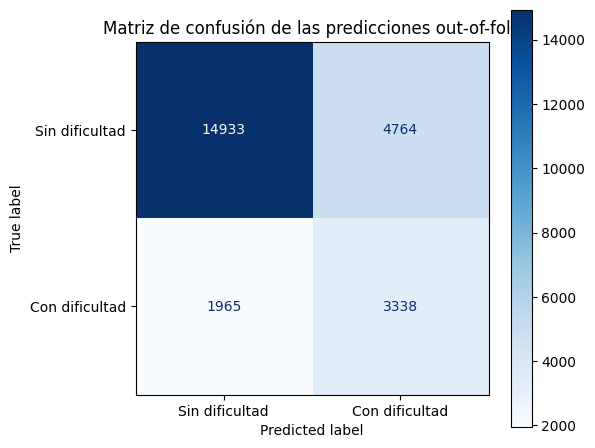

In [84]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y,
    oof_predictions,
    display_labels=[
        "Sin dificultad",
        "Con dificultad"
    ],
    cmap="Blues",
    ax=ax
)

ax.set_title(
    "Matriz de confusión de las predicciones out-of-fold"
)

plt.tight_layout()
plt.show()

In [85]:
print(
    classification_report(
        y,
        oof_predictions,
        target_names=[
            "Sin dificultad",
            "Con dificultad"
        ],
        digits=4
    )
)

                precision    recall  f1-score   support

Sin dificultad     0.8837    0.7581    0.8161     19697
Con dificultad     0.4120    0.6295    0.4980      5303

      accuracy                         0.7308     25000
     macro avg     0.6479    0.6938    0.6571     25000
  weighted avg     0.7837    0.7308    0.7486     25000



In [86]:
results_table = pd.DataFrame({
    "Clasificador": [
        "DecisionTreeClassifier"
    ],
    "Configuración principal": [
        f"max_depth=6, min_samples_leaf=200, "
        f"{len(SELECTED_FEATURES)} predictors (forward selection)"
    ],
    "Umbral": [
        CHOSEN_THRESHOLD
    ],
    "Accuracy CV": [
        accuracy_score(y, oof_predictions)
    ],
    "Balanced accuracy CV": [
        balanced_accuracy_score(y, oof_predictions)
    ],
    "F1 CV": [
        f1_score(y, oof_predictions)
    ],
    "ROC-AUC CV": [
        final_cv_results["test_roc_auc"].mean()
    ],
    "ROC-AUC std": [
        final_cv_results["test_roc_auc"].std()
    ]
})

results_table.round(4)


,Clasificador,Configuración principal,Umbral,Accuracy CV,Balanced accuracy CV,F1 CV,ROC-AUC CV,ROC-AUC std
0,DecisionTreeClassifier,"max_depth=6, min_samples_leaf=200, 4 predictor...",0.22,0.7308,0.6938,0.498,0.7584,0.0045


## 9. Preliminary Discussion

The unrestricted decision tree showed substantial overfitting, achieving
almost perfect performance on the training data but a mean ROC-AUC of
approximately 0.595 under cross-validation. In addition, the resulting tree
contained 8,911 nodes and 4,456 leaves, making it considerably more difficult
to interpret.

Restricting model complexity improved both generalization and interpretability.
The final model uses a maximum depth of 6 and a minimum of 200 observations per
leaf. Forward selection then retained four predictors
(`payment_to_bill_ratio_6m`, `latest_repayment_status`,
`repayment_assistance_plan` and `age`), which achieve a mean ROC-AUC of
approximately 0.758 under five-fold cross-validation, close to the best subset
and slightly above the full 15-predictor model (approximately 0.756). The more
compact model is therefore preferred. Because the same cross-validation was
used to choose the predictors, this estimate is mildly optimistic.

The model relies mainly on information related to payment behavior, in
particular `payment_to_bill_ratio_6m` and `latest_repayment_status`, together
with the repayment assistance flag and age. The learned rules identify regions
with substantially different payment difficulty profiles across the leaves.

These associations describe the predictive behavior of the tree and should not
be interpreted as causal relationships. This is particularly relevant for
features such as `repayment_assistance_plan`, whose presence may be associated
with prior information about the customer's situation.

Finally, the reported metrics depend on the classification threshold. At the
default threshold of 0.5 the model reaches high accuracy (0.809) but misses
most positive cases (recall 0.230). Selecting the threshold on the out-of-fold
predictions by balanced accuracy gives 0.22, which raises recall to 0.630 and
balanced accuracy to 0.694, at the cost of accuracy (0.731). The threshold was
chosen without using the test set.


### Selected Cases for Local Explanations

To facilitate a subsequent comparison between models, the following
observations will be retained:

- **CR26-108758**: true class 1. The final decision tree predicts class 1 with
  an estimated probability of approximately 0.448.
- **CR26-103896**: true class 0. The final decision tree predicts class 0 with
  an estimated probability of class 1 of approximately 0.094.

The same cases will subsequently be used to analyze and compare the local
explanations produced by the different models.
